In [1]:
import sys
from pathlib import Path

repo_root = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN')
sys.path.insert(0, str(repo_root))


### 1. Configuração do Ambiente

In [ ]:
#!pip install "cognite-sdk[pandas]" matplotlib seaborn tensorflow plotly -q

import os
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.stattools import acf
from industrial_ts.dataloader import DataLoader
import json
from getpass import getpass
#import tensorflow as tf
#from tensorflow import keras

print("Bibliotecas importadas com sucesso!")






Updated: UnsupervisedStateSegmenter now supports multi-channel (multivariate) series.

Bibliotecas importadas com sucesso!


/home/ferna/fe/lib/python3.12/site-packages/ipykernel/ipkernel.py:772: UserWarning: You are using version='7.83.1' of the SDK, however version='7.91.2' is available. To suppress this warning, either upgrade or do the following:
>>> from cognite.client.config import global_config
>>> global_config.disable_pypi_version_check = True
  _threading_Thread_run(self)


In [3]:
import debugpy
debugpy.listen(('0.0.0.0', 5678))






('0.0.0.0', 5678)

In [4]:
os.environ['COGNITE_CLIENT_SECRET'] = getpass("Enter COGNITE_CLIENT")






### 2. Ativar o DataLoader

In [5]:
import importlib
import sys
importlib.reload(sys.modules['industrial_ts.dataloader'])
from industrial_ts.dataloader import DataLoader
dl = DataLoader()
dl.add_segments(segments=3, window=10, step=10, series=[
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActShaft Power',
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActPress Ratio'  
], path="segmenter_model_10.pkl"
)
#dl.segmenter.save("segmenter_model_10.pkl")








Buscando dados para as 12 séries temporais encontradas.


### 10 Pós-processamento

In [6]:
for i in [2]:
    dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2







/tmp/ipykernel_30355/4230046523.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2


In [7]:
dl.add_time_to_change_state_timestamp()






## Experimento Baseline GRU

In [9]:
from pathlib import Path
import json
import time
from industrial_ts.gru import TSDF_GRU

# --- Resumo para salvar no JSON ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

# Best epoch by test micro
def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')


# --- Nome do arquivo baseado na configuracao ---
def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_gru(cfg):
    tp = cfg.get('train_params', {})
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    lr = tp.get('optimizer_params', {}).get('lr', 'lr')
    return _safe(f"gru_{clamp}_{opt}_lr{lr}")


# --- Config base (se nao existir do TSDF_seqKAN) ---
if 'run_config' not in globals():
    batch_size = 512
    run_config = dict(
        model='TSDF_seqKAN',
        in_channels=11,
        hidden_dim=11*32,
        cost_columns=[
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActShaft Power',
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActPress Ratio'
        ],
        lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        sigma_temp=0.6,
        log_likelihood=False,
        use_layernorm=False,
        direct_x=True,
        train_params=dict(
            batch_size=batch_size,
            window_size=10,
            window_step=10,
            epochs=150,
            validate=True,
            patience=20,
            kl_warmup_epochs=20,
            kl_start=0.01,
            rebuild=True,
            reconstruction_test=False,
            warmup_steps=0,
            min_lr_factor=1.0,
            optimizer_name='radam',
            optimizer_params={'lr': 2e-4},
            grad_clip_max_norm=0.3,
            debug_batch_stats=True,
            x_min=-3.0,
            x_max=3.0,
        ),
    )

# --- defaults se run_config veio de outra celula ---
if 'cost_columns' not in run_config:
    run_config['cost_columns'] = [
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActPress Ratio'
    ]
if 'lam' not in run_config:
    run_config['lam'] = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
if 'sigma_temp' not in run_config:
    run_config['sigma_temp'] = 0.6
if 'log_likelihood' not in run_config:
    run_config['log_likelihood'] = False
if 'use_layernorm' not in run_config:
    run_config['use_layernorm'] = False
if 'train_params' not in run_config:
    run_config['train_params'] = {}

run_config_gru = dict(
    model='TSDF_GRU',
    in_channels=run_config['in_channels'],
    hidden_dim=run_config['hidden_dim'],
    cost_columns=run_config['cost_columns'],
    lam=run_config['lam'],
    sigma_temp=run_config['sigma_temp'],
    log_likelihood=run_config['log_likelihood'],
    use_layernorm=run_config['use_layernorm'],
    train_params=run_config['train_params'],
)

run_name_gru = _make_run_name_gru(run_config_gru)
out_json_gru = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"final_rebuild_{run_name_gru}.json")

# Garante sem clamp para GRU

model_gru = TSDF_GRU(
    in_channels=run_config_gru['in_channels'],
    hidden_dim=run_config_gru['hidden_dim'],
    cost_columns=run_config_gru['cost_columns'],
    lam=run_config_gru['lam'],
    sigma_temp=run_config_gru['sigma_temp'],
    log_likelihood=run_config_gru['log_likelihood'],
    use_layernorm=run_config_gru['use_layernorm'],
)

train_start_gru = time.time()
res_gru = model_gru.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_gru['train_params']['batch_size'],
    window_size=run_config_gru['train_params']['window_size'],
    window_step=run_config_gru['train_params']['window_step'],
    epochs=run_config_gru['train_params']['epochs'],
    validate=run_config_gru['train_params']['validate'],
    patience=run_config_gru['train_params']['patience'],
    kl_warmup_epochs=run_config_gru['train_params']['kl_warmup_epochs'],
    kl_start=run_config_gru['train_params']['kl_start'],
    rebuild=run_config_gru['train_params']['rebuild'],
    reconstruction_test=run_config_gru['train_params']['reconstruction_test'],
    warmup_steps=run_config_gru['train_params']['warmup_steps'],
    min_lr_factor=run_config_gru['train_params']['min_lr_factor'],
    optimizer_name=run_config_gru['train_params']['optimizer_name'],
    optimizer_params=run_config_gru['train_params']['optimizer_params'],
    grad_clip_max_norm=run_config_gru['train_params']['grad_clip_max_norm'],
    debug_batch_stats=run_config_gru['train_params']['debug_batch_stats'],
    debug_batch_stats_names=list(dl.df.columns[:-3]),
    x_min=run_config_gru['train_params']['x_min'],
    x_max=run_config_gru['train_params']['x_max'],
)
train_end_gru = time.time()
train_seconds_gru = train_end_gru - train_start_gru

res_gru = [r for r in res_gru if r is not None]
out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
gru_ckpt = out_dir / f"{run_name_gru}.pt"
model_gru.save(str(gru_ckpt))
print('saved model:', gru_ckpt)

# Best epoch by test micro
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_gru)
summary = _extract_summary(res_gru)

with open(out_json_gru, 'w') as f:
    payload = {
        'config': run_config_gru,
        'results': res_gru,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_gru,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    json.dump(payload, f)

print(res_gru[-1] if res_gru else 'no results')
print('saved:', out_json_gru)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:735: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


GRUPOS (total): {0: 24346, 1: 2637}
GRUPOS (train): {0: 14608, 1: 1582}
GRUPOS (valid): {0: 4869, 1: 528}
GRUPOS (test):  {0: 4869, 1: 527}
>% |x| > 2 : 7.18%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.000000 0.008580 2.285053]
worst_min_feature: PH (CBM) 1st Stage ExpPress Ratio -3.0
worst_max_feature: PH (CBM) 1st Stage Poly Head Dev 3.0
Epoch 1/150 | Train(sampled) L1:0.794413 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.680750 ± 0.275945 | Val micro:0.459880 ± 0.008741 
          >> Test macro:0.691338 ± 0.291220 | micro:0.458097 ± 0.008257
>% |x| > 2 : 6.69%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.000000 0.027401 2.275320]
worst_min_feature: PH (CBM) 1st Stage ExpPress Ratio -3.0
worst_max_feature: PH (CBM) 1st Stage Poly Head Dev 3.0
Epoch 2/150 | Train(sampled) L1:0.569989 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.413173 ± 0.155294 | Val micro:0.288874 ± 

# TS_seqKANseq

In [10]:
import importlib
import industrial_ts.seqKAN as sk
importlib.reload(sk)
from industrial_ts.seqKAN import TS_seqKANSeq


In [11]:
# checar NaN/Inf nos dados
import numpy as np
import torch

X = dl.df[list(dl.df.columns[:-3])].to_numpy(dtype=float)
print("X finite:", np.isfinite(X).all())
print("X min/max:", np.nanmin(X), np.nanmax(X))


X finite: False
X min/max: -742.3485040586738 13490.5939278987


In [12]:
import numpy as np

feature_cols = list(dl.df.columns[:-3])
df_feat = dl.df[feature_cols].apply(pd.to_numeric, errors='coerce')
df_feat = df_feat.replace([np.inf, -np.inf], np.nan)
df_feat = df_feat.interpolate(limit_direction='both')
df_feat = df_feat.fillna(df_feat.median())

dl.df[feature_cols] = df_feat

# clamp no mesmo range do treinoS
dl.df[feature_cols] = dl.df[feature_cols].clip(-3.0, 3.0)


In [13]:
# Treino via train_cognite com TS_seqKANSeq (rebuild-only, 11 dims)
from industrial_ts.seqKAN import TS_seqKANSeq
import time
import json as _json
from pathlib import Path

kan_params_seq = {
    'cell': {'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'output': {'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
    'topk': {
        'enabled': True,
        'k_x': 4,
        'k_h': 6,
        'k_out': 4,
        'warmup_epochs': 30,
        'mode': 'soft',
        'temp': 0.5,
    },
}

batch_size = 512
train_fraction = 0.6

run_config = dict(
    model='TS_seqKANSeq',
    in_channels=11,
    hidden_dim=24,
    output_dim=11,
    kan_params=kan_params_seq,
    train_params=dict(
        cost_columns=[
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActShaft Power',
            'PH (CBM) 1st Stg ActCompr Poly Head',
            'PH (CBM) 1st Stage ActPress Ratio',
        ],
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=80,
        validate=True,
        patience=10,
        train_fraction=train_fraction,
        seed_split=42,
        fixed_test_idx=None,
        use_group_sampler=True,
        horizon=1,
        rebuild=True,
        reconstruction_test=False,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        use_robust_scaler=True,
        x_min=-3.0,
        x_max=3.0,
        log_every=10,
    ),
)

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    kp = cfg.get('kan_params', {})
    grid_c = kp.get('cell', {}).get('grid', 'g?')
    grid_eps = kp.get('cell', {}).get('grid_eps', kp.get('grid_eps', 'ge?'))
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    lr = tp.get('optimizer_params', {}).get('lr', 'lr')
    h = cfg.get('hidden_dim', 'H?')
    return _safe(f"seqKANseq_H{h}_g{grid_c}_ge{grid_eps}_{clamp}_{opt}_lr{lr}")

run_name = _make_run_name_seqkanseq(run_config)
out_json = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"final_rebuild_{run_name}.json")

model_seq = TS_seqKANSeq(
    in_channels=run_config['in_channels'],
    hidden_dim=run_config['hidden_dim'],
    output_dim=run_config['output_dim'],
    kan_params=run_config['kan_params'],
)

train_start = time.time()
res = model_seq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config['train_params']['batch_size'],
    window_size=run_config['train_params']['window_size'],
    window_step=run_config['train_params']['window_step'],
    epochs=run_config['train_params']['epochs'],
    validate=run_config['train_params']['validate'],
    patience=run_config['train_params']['patience'],
    train_fraction=run_config['train_params']['train_fraction'],
    seed_split=run_config['train_params']['seed_split'],
    fixed_test_idx=run_config['train_params']['fixed_test_idx'],
    use_group_sampler=run_config['train_params']['use_group_sampler'],
    horizon=run_config['train_params']['horizon'],
    rebuild=run_config['train_params']['rebuild'],
    reconstruction_test=run_config['train_params']['reconstruction_test'],
    cost_columns=run_config['train_params']['cost_columns'],
    optimizer_name=run_config['train_params']['optimizer_name'],
    optimizer_params=run_config['train_params']['optimizer_params'],
    use_robust_scaler=run_config['train_params']['use_robust_scaler'],
    x_min=run_config['train_params']['x_min'],
    x_max=run_config['train_params']['x_max'],
    log_every=run_config['train_params']['log_every'],
)
train_end = time.time()
train_seconds = train_end - train_start

res = [r for r in res if r is not None]
out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
seqkanseq_ckpt = out_dir / f"{run_name}.pt"
import torch
torch.save(model_seq.state_dict(), seqkanseq_ckpt)
print('saved model:', seqkanseq_ckpt)

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

summary = _extract_summary(res)

def _json_safe(o):
    import numpy as _np
    if isinstance(o, dict):
        return {k: _json_safe(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_json_safe(v) for v in o]
    if isinstance(o, _np.ndarray):
        return o.tolist()
    if isinstance(o, _np.floating):
        return float(o)
    if isinstance(o, _np.integer):
        return int(o)
    return o

best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res)

with open(out_json, 'w') as f:
    payload = {
        'config': run_config,
        'results': res,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds,
        'best_epoch': summary['best_epoch'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(_json_safe(payload), f)

print(res[-1] if res else 'no results')
print('saved:', out_json)


GRUPOS (total): {0: 24346, 1: 2637}
GRUPOS (train): {0: 14608, 1: 1582}
GRUPOS (valid): {0: 4869, 1: 528}
GRUPOS (test):  {0: 4869, 1: 527}
train/val/test batches: 32/11/11
Epoch 1/80 | step 10/32 | train 0.029422
Epoch 1/80 | step 20/32 | train 0.028366
Epoch 1/80 | step 30/32 | train 0.030304
Epoch 1/80 | Train(sampled) L1:0.030127 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.037783 ± 0.010491 | Val micro:0.029345 ± 0.004300
          >> Test macro:0.020544 ± 0.003375 | micro:0.023260 ± 0.003043
          >> per_group (weighted SE): {0: '0.023919 ± 0.003372 (n=4869)', 1: '0.017169 ± 0.000009 (n=527)'}
Epoch 2/80 | step 10/32 | train 0.028028
Epoch 2/80 | step 20/32 | train 0.028487
Epoch 2/80 | step 30/32 | train 0.027199
Epoch 2/80 | Train(sampled) L1:0.026134 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.030904 ± 0.010735 | Val micro:0.022270 ± 0.004400
          >> Test macro:0.013266 ± 0.003452 | micro:0.016043 ± 0.003113

# TSDF_seqKAN

In [ ]:
# Treino via train_cognite com TSDF_seqKAN
from industrial_ts.seqKAN import TSDF_seqKAN
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_seqkan(cfg):
    tp = cfg.get('train_params', {})
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    lr = tp.get('optimizer_params', {}).get('lr', 'lr')
    h = cfg.get('hidden_dim', 'H?')
    return _safe(f"seqKAN_H{h}_{clamp}_{opt}_lr{lr}")

# config standalone (nao depende de run_config)
if 'kan_params_seq' not in globals():
    kan_params_seq = {
        'cell': {'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
        'output': {'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
        'topk': {
            'enabled': True,
            'k_x': 4,
            'k_h': 6,
            'k_out': 4,
            'warmup_epochs': 30,
            'mode': 'soft',
            'temp': 0.5,
        },
    }

batch_size = 512
train_fraction = 0.6

run_config_seqkan = dict(
    model='TSDF_seqKAN',
    in_channels=11,
    hidden_dim=24,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=150,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        grad_clip_max_norm=0.3,
        debug_batch_stats=True,
        x_min=-3.0,
        x_max=3.0,
    ),
)
run_name_seqkan = _make_run_name_seqkan(run_config_seqkan)
out_json_seqkan = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"final_rebuild_{run_name_seqkan}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')


model_seqkan = TSDF_seqKAN(
    in_channels=run_config_seqkan['in_channels'],
    hidden_dim=run_config_seqkan['hidden_dim'],
    cost_columns=run_config_seqkan['cost_columns'],
    lam=run_config_seqkan['lam'],
    sigma_temp=run_config_seqkan['sigma_temp'],
    log_likelihood=run_config_seqkan['log_likelihood'],
    use_layernorm=run_config_seqkan['use_layernorm'],
    direct_x=run_config_seqkan['direct_x'],
    kan_params=run_config_seqkan['kan_params'],
)

train_start_seqkan = time.time()
res_seqkan = model_seqkan.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_seqkan['train_params']['batch_size'],
    window_size=run_config_seqkan['train_params']['window_size'],
    window_step=run_config_seqkan['train_params']['window_step'],
    epochs=run_config_seqkan['train_params']['epochs'],
    validate=run_config_seqkan['train_params']['validate'],
    patience=run_config_seqkan['train_params']['patience'],
    kl_warmup_epochs=run_config_seqkan['train_params']['kl_warmup_epochs'],
    kl_start=run_config_seqkan['train_params']['kl_start'],
    rebuild=run_config_seqkan['train_params']['rebuild'],
    reconstruction_test=run_config_seqkan['train_params']['reconstruction_test'],
    warmup_steps=run_config_seqkan['train_params']['warmup_steps'],
    min_lr_factor=run_config_seqkan['train_params']['min_lr_factor'],
    optimizer_name=run_config_seqkan['train_params']['optimizer_name'],
    optimizer_params=run_config_seqkan['train_params']['optimizer_params'],
    grad_clip_max_norm=run_config_seqkan['train_params']['grad_clip_max_norm'],
    debug_batch_stats=run_config_seqkan['train_params']['debug_batch_stats'],
    debug_batch_stats_names=list(dl.df.columns[:-3]),
    x_min=run_config_seqkan['train_params']['x_min'],
    x_max=run_config_seqkan['train_params']['x_max'],
)
train_end_seqkan = time.time()
train_seconds_seqkan = train_end_seqkan - train_start_seqkan

res_seqkan = [r for r in res_seqkan if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
seqkan_ckpt = out_dir / f"{run_name_seqkan}.pt"
import torch
torch.save(model_seqkan.state_dict(), seqkan_ckpt)
print('saved model:', seqkan_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_seqkan)
summary = _extract_summary(res_seqkan)

with open(out_json_seqkan, 'w') as f:
    payload = {
        'config': run_config_seqkan,
        'results': res_seqkan,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_seqkan,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_seqkan[-1] if res_seqkan else 'no results')
print('saved:', out_json_seqkan)


/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:737: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


GRUPOS (total): {0: 24346, 1: 2637}
GRUPOS (train): {0: 14608, 1: 1582}
GRUPOS (valid): {0: 4869, 1: 528}
GRUPOS (test):  {0: 4869, 1: 527}
>% |x| > 2 : 7.52%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.000000 0.010034 2.367815]
worst_min_feature: PH (CBM) 1st Stage ExpPress Ratio -3.0
worst_max_feature: PH (CBM) 1st Stage Poly Head Dev 3.0
Epoch 1/150 | Train(sampled) L1:0.823938 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.818954 ± 0.336534 | Val micro:0.549588 ± 0.009738 
          >> Test macro:0.815290 ± 0.332225 | micro:0.549208 ± 0.009261
>% |x| > 2 : 8.01%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.000000 -0.004624 2.307627]
worst_min_feature: PH (CBM) 1st Stage ExpPress Ratio -3.0
worst_max_feature: PH (CBM) 1st Stage Poly Head Dev 3.0
Epoch 2/150 | Train(sampled) L1:0.833544 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.817758 ± 0.338609 | Val micro:0.546732 ±

# TSDF_seqKANseq

In [9]:
# Treino via train_cognite com TSDF_seqKANSeq
from industrial_ts.seqKAN import TSDF_seqKANSeq
import time
import json as _json
from pathlib import Path

def _safe(s):
    return ''.join(c if c.isalnum() or c in '-_.' else '_' for c in str(s))

def _make_run_name_tsdf_seqkanseq(cfg):
    tp = cfg.get('train_params', {})
    clamp = f"c{tp.get('x_min')}_{tp.get('x_max')}"
    opt = _safe(tp.get('optimizer_name', 'opt'))
    lr = tp.get('optimizer_params', {}).get('lr', 'lr')
    h = cfg.get('hidden_dim', 'H?')
    return _safe(f"tsdf_seqKANseq_H{h}_{clamp}_{opt}_lr{lr}")

# config standalone (nao depende de outras celulas)
if 'kan_params_seq' not in globals():
    kan_params_seq = {
        'cell': {'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
        'output': {'grid': 8, 'k': 3, 'grid_range': (-3, 3)},
        'topk': {
            'enabled': True,
            'k_x': 4,
            'k_h': 6,
            'k_out': 4,
            'warmup_epochs': 30,
            'mode': 'soft',
            'temp': 0.5,
        },
    }

batch_size = 512
train_fraction = 0.6

run_config_tsdf_seqkanseq = dict(
    model='TSDF_seqKANSeq',
    in_channels=11,
    hidden_dim=24,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActPress Ratio',
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params_seq,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=150,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        grad_clip_max_norm=0.3,
        debug_batch_stats=True,
        x_min=-3.0,
        x_max=3.0,
    ),
)

run_name_tsdf_seqkanseq = _make_run_name_tsdf_seqkanseq(run_config_tsdf_seqkanseq)
out_json_tsdf_seqkanseq = str(Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results') / f"final_rebuild_{run_name_tsdf_seqkanseq}.json")

# --- Resumo para salvar no JSON (mesmo padrao do GRU) ---
def _extract_summary(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return {
            'best_epoch': None,
            'L1_best': None,
            'L1_final': None,
            'Test_best': None,
            'Test_final': None,
            'per_group_best': None,
            'per_group_final': None,
            'best_val_epoch': None,
            'best_val_micro': None,
        }

    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    last = metrics[-1]

    if 'val_micro' in metrics[0]:
        best_val = min(metrics, key=lambda m: m.get('val_micro', float('inf')))
    else:
        best_val = None

    def _pack_test(m):
        if m is None:
            return None
        return {
            'micro_mse': m.get('micro_mse'),
            'micro_se': m.get('micro_se'),
            'macro_mse': m.get('macro_mse'),
            'macro_se': m.get('macro_se'),
        }

    def _pack_groups(m):
        if m is None:
            return None
        return {
            'mse': m.get('per_group_mse'),
            'se_w': m.get('per_group_se_w'),
            'se_unw': m.get('per_group_se_unw'),
            'counts': m.get('per_group_counts'),
            'sum_nobs': m.get('per_group_sum_nobs'),
        }

    return {
        'best_epoch': best.get('epoch'),
        'L1_best': best.get('train_L1'),
        'L1_final': last.get('train_L1'),
        'Test_best': _pack_test(best),
        'Test_final': _pack_test(last),
        'per_group_best': _pack_groups(best),
        'per_group_final': _pack_groups(last),
        'best_val_epoch': best_val.get('epoch') if best_val is not None else None,
        'best_val_micro': best_val.get('val_micro') if best_val is not None else None,
    }

def _best_epoch_by_test_micro(res):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    best = min(metrics, key=lambda m: m.get('micro_mse', float('inf')))
    return best.get('epoch'), best.get('micro_mse')

model_tsdf_seqkanseq = TSDF_seqKANSeq(
    in_channels=run_config_tsdf_seqkanseq['in_channels'],
    hidden_dim=run_config_tsdf_seqkanseq['hidden_dim'],
    cost_columns=run_config_tsdf_seqkanseq['cost_columns'],
    lam=run_config_tsdf_seqkanseq['lam'],
    sigma_temp=run_config_tsdf_seqkanseq['sigma_temp'],
    log_likelihood=run_config_tsdf_seqkanseq['log_likelihood'],
    use_layernorm=run_config_tsdf_seqkanseq['use_layernorm'],
    direct_x=run_config_tsdf_seqkanseq['direct_x'],
    kan_params=run_config_tsdf_seqkanseq['kan_params'],
)

train_start_tsdf_seqkanseq = time.time()
res_tsdf_seqkanseq = model_tsdf_seqkanseq.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config_tsdf_seqkanseq['train_params']['batch_size'],
    window_size=run_config_tsdf_seqkanseq['train_params']['window_size'],
    window_step=run_config_tsdf_seqkanseq['train_params']['window_step'],
    epochs=run_config_tsdf_seqkanseq['train_params']['epochs'],
    validate=run_config_tsdf_seqkanseq['train_params']['validate'],
    patience=run_config_tsdf_seqkanseq['train_params']['patience'],
    kl_warmup_epochs=run_config_tsdf_seqkanseq['train_params']['kl_warmup_epochs'],
    kl_start=run_config_tsdf_seqkanseq['train_params']['kl_start'],
    rebuild=run_config_tsdf_seqkanseq['train_params']['rebuild'],
    reconstruction_test=run_config_tsdf_seqkanseq['train_params']['reconstruction_test'],
    warmup_steps=run_config_tsdf_seqkanseq['train_params']['warmup_steps'],
    min_lr_factor=run_config_tsdf_seqkanseq['train_params']['min_lr_factor'],
    optimizer_name=run_config_tsdf_seqkanseq['train_params']['optimizer_name'],
    optimizer_params=run_config_tsdf_seqkanseq['train_params']['optimizer_params'],
    grad_clip_max_norm=run_config_tsdf_seqkanseq['train_params']['grad_clip_max_norm'],
    debug_batch_stats=run_config_tsdf_seqkanseq['train_params']['debug_batch_stats'],
    debug_batch_stats_names=list(dl.df.columns[:-3]),
    x_min=run_config_tsdf_seqkanseq['train_params']['x_min'],
    x_max=run_config_tsdf_seqkanseq['train_params']['x_max'],
)
train_end_tsdf_seqkanseq = time.time()
train_seconds_tsdf_seqkanseq = train_end_tsdf_seqkanseq - train_start_tsdf_seqkanseq

res_tsdf_seqkanseq = [r for r in res_tsdf_seqkanseq if r is not None]

out_dir = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results')
out_dir.mkdir(parents=True, exist_ok=True)
tsdf_seqkanseq_ckpt = out_dir / f"{run_name_tsdf_seqkanseq}.pt"
import torch
torch.save(model_tsdf_seqkanseq.state_dict(), tsdf_seqkanseq_ckpt)
print('saved model:', tsdf_seqkanseq_ckpt)

# resumo no mesmo padrao do GRU
best_epoch_test_micro, best_test_micro = _best_epoch_by_test_micro(res_tsdf_seqkanseq)
summary = _extract_summary(res_tsdf_seqkanseq)

with open(out_json_tsdf_seqkanseq, 'w') as f:
    payload = {
        'config': run_config_tsdf_seqkanseq,
        'results': res_tsdf_seqkanseq,
        'best_epoch_test_micro': best_epoch_test_micro,
        'best_test_micro': best_test_micro,
        'train_seconds': train_seconds_tsdf_seqkanseq,
        'best_epoch': summary['best_epoch'],
        'best_val_epoch': summary['best_val_epoch'],
        'best_val_micro': summary['best_val_micro'],
        'L1_best': summary['L1_best'],
        'L1_final': summary['L1_final'],
        'Test_best': summary['Test_best'],
        'Test_final': summary['Test_final'],
        'per_group_best': summary['per_group_best'],
        'per_group_final': summary['per_group_final'],
    }
    _json.dump(payload, f)

print(res_tsdf_seqkanseq[-1] if res_tsdf_seqkanseq else 'no results')
print('saved:', out_json_tsdf_seqkanseq)


/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:737: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


GRUPOS (total): {0: 24346, 1: 2637}
GRUPOS (train): {0: 14608, 1: 1582}
GRUPOS (valid): {0: 4869, 1: 528}
GRUPOS (test):  {0: 4869, 1: 527}
>% |x| > 2 : 7.52%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.000000 0.010034 2.367815]
worst_min_feature: PH (CBM) 1st Stage ExpPress Ratio -3.0
worst_max_feature: PH (CBM) 1st Stage Poly Head Dev 3.0
Epoch 1/150 | Train(sampled) L1:0.823938 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.818954 ± 0.336534 | Val micro:0.549588 ± 0.009738 
          >> Test macro:0.815290 ± 0.332225 | micro:0.549208 ± 0.009261
>% |x| > 2 : 8.01%
>% |x| > 3 : 0.00%
>% |x| > 4 : 0.00%
min: -3.0 max: 3.0
p1/p50/p99: [-3.000000 -0.004624 2.307627]
worst_min_feature: PH (CBM) 1st Stage ExpPress Ratio -3.0
worst_max_feature: PH (CBM) 1st Stage Poly Head Dev 3.0
Epoch 2/150 | Train(sampled) L1:0.833544 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.817758 ± 0.338609 | Val micro:0.546732 ±

# Valores fora do clamp

In [15]:
import numpy as np
import torch
from industrial_ts.ode_jump import ODEJump

X = dl.df.iloc[:, :-3].to_numpy(dtype=float)

train_idx = np.arange(int(0.6 * len(X)))

X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, C)
X_scaled = ODEJump.scale_tensor(X_t[train_idx], X_t).squeeze(1).cpu().numpy()

total = X_scaled.size
abs_x = np.abs(X_scaled)
count_out = int((abs_x > 3).sum())
pct_out = 100.0 * count_out / total

p1, p50, p99 = np.percentile(X_scaled, [1, 50, 99])
x_min = float(X_scaled.min())
x_max = float(X_scaled.max())

print(f"Total valores: {total}")
print(f"|x| > 3: {count_out} ({pct_out:.2f}%)")
print(f"min: {x_min:.3f} max: {x_max:.3f}")
print(f"p1/p50/p99: [{p1:.6f} {p50:.6f} {p99:.6f}]")


Total valores: 2968130
|x| > 3: 19580 (0.66%)
min: -45.930 max: 0.000
p1/p50/p99: [-2.303805 0.000000 0.000000]


In [16]:
import numpy as np
import torch
from industrial_ts.ode_jump import ODEJump

# dados e nomes
cols = list(dl.df.columns[:-3])
X = dl.df.iloc[:, :-3].to_numpy(dtype=float)

# mesma escala do modelo (fit no treino)
train_idx = np.arange(int(0.6 * len(X)))  # ajuste se tiver train_idx real
X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,C)
X_scaled = ODEJump.scale_tensor(X_t[train_idx], X_t).squeeze(1).cpu().numpy()

# métricas por feature
absX = np.abs(X_scaled)
pct_gt3 = (absX > 3).mean(axis=0) * 100
mins = X_scaled.min(axis=0)
maxs = X_scaled.max(axis=0)
p99 = np.percentile(X_scaled, 99, axis=0)

# ordena por maior %>|3|
order = np.argsort(-pct_gt3)

print("top features por %|x|>3 (scaled):")
for i in order[:20]:
    print(f"{cols[i]:60s}  %>|3|={pct_gt3[i]:6.2f}  min={mins[i]:8.3f}  max={maxs[i]:8.3f}  p99={p99[i]:8.3f}")


top features por %|x|>3 (scaled):
PH (CBM) 1st Stage ExpPress Ratio                             %>|3|=  6.91  min= -45.930  max=   0.000  p99=   0.000
PH (CBM) 1st Stage Poly Head Dev                              %>|3|=  0.18  min=  -6.000  max=   0.000  p99=   0.000
PH (CBM) 1st Stage Shft Pwr Dev                               %>|3|=  0.11  min=  -6.000  max=   0.000  p99=   0.000
PH (CBM) 1st Stage Press Rat Dev                              %>|3|=  0.05  min=  -6.000  max=   0.000  p99=   0.000
PH (CBM) 1st Stage ActShaft Power                             %>|3|=  0.00  min=  -6.000  max=   0.000  p99=   0.000
PH (CBM) 1st Stage ActCompr Poly Eff                          %>|3|=  0.00  min=  -6.000  max=   0.000  p99=   0.000
PH (CBM) 1st Stg ActCompr Poly Head                           %>|3|=  0.00  min=  -3.000  max=   0.000  p99=   0.000
PH (CBM) 1st Stage ExpCompr Poly Eff                          %>|3|=  0.00  min=  -3.000  max=   0.000  p99=   0.000
PH (CBM) 1st Stage ExpShaft Po

In [17]:
import numpy as np
import torch
from industrial_ts.ode_jump import ODEJump

cols = list(dl.df.columns[:-3])
feat = "PH (CBM) 1st Stage ExpPress Ratio"

X = dl.df.iloc[:, :-3].to_numpy(dtype=float)
train_idx = np.arange(int(0.6 * len(X)))  # ajuste se tiver o train_idx real
X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
X_scaled = ODEJump.scale_tensor(X_t[train_idx], X_t).squeeze(1).cpu().numpy()

j = cols.index(feat)
mask = np.abs(X_scaled[:, j]) > 3

count = int(mask.sum())
total = len(mask)
pct = 100.0 * count / total

print(f"{feat}")
print(f"Total timestamps: {total}")
print(f"|x| > 3: {count} ({pct:.2f}%)")

# mostra alguns timestamps e valores originais/escalados
idx = np.where(mask)[0][:10]
print("exemplos (index, raw, scaled):")
for i in idx:
    raw = X[i, j]
    sc = X_scaled[i, j]
    ts = dl.df.index[i]  # se o índice for datetime
    print(i, ts, f"raw={raw:.6f}", f"scaled={sc:.6f}")


PH (CBM) 1st Stage ExpPress Ratio
Total timestamps: 269830
|x| > 3: 18653 (6.91%)
exemplos (index, raw, scaled):
0 2019-09-01 03:00:16 raw=2.456634 scaled=-8.318924
1 2019-09-01 03:00:46 raw=2.759697 scaled=-3.679043
2 2019-09-01 03:01:16 raw=2.790394 scaled=-3.209063
3 2019-09-01 03:01:46 raw=2.687855 scaled=-4.778935
6 2019-09-01 03:03:16 raw=2.643832 scaled=-5.452930
8 2019-09-01 03:04:16 raw=2.727711 scaled=-4.168737
9 2019-09-01 03:04:46 raw=2.705648 scaled=-4.506525
11 2019-09-01 03:05:46 raw=2.672619 scaled=-5.012189
12 2019-09-01 03:06:16 raw=2.794599 scaled=-3.144678
16 2019-09-01 03:08:16 raw=2.753382 scaled=-3.775718


# Extrair parametros das splines do seqKANseq  

 Requer que `model_seq` (TS_seqKANSeq) ja exista

In [ ]:

import json
from pathlib import Path

out_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')


def _kanlayer_to_dict(kl):
    d = {}
    d['in_dim'] = int(getattr(kl, 'in_dim', -1))
    d['out_dim'] = int(getattr(kl, 'out_dim', -1))
    d['num'] = int(getattr(kl, 'num', -1))
    d['k'] = int(getattr(kl, 'k', -1))
    d['grid'] = kl.grid.detach().cpu().tolist() if hasattr(kl, 'grid') else None
    d['coef'] = kl.coef.detach().cpu().tolist() if hasattr(kl, 'coef') else None
    d['scale_sp'] = kl.scale_sp.detach().cpu().tolist() if hasattr(kl, 'scale_sp') else None
    d['scale_base'] = kl.scale_base.detach().cpu().tolist() if hasattr(kl, 'scale_base') else None
    d['mask'] = kl.mask.detach().cpu().tolist() if hasattr(kl, 'mask') else None
    d['base_fun'] = kl.base_fun.__class__.__name__ if hasattr(kl, 'base_fun') else None
    return d


def _multkan_to_dict(kan):
    # ArticleKAN (MultKAN) -> lista de KANLayer em act_fun
    out = {
        'class': kan.__class__.__name__,
        'width': getattr(kan, 'width', None),
        'grid_eps': getattr(kan, 'grid_eps', None),
        'grid_range': getattr(kan, 'grid_range', None),
        'base_fun_name': getattr(kan, 'base_fun_name', None),
        'layers': [],
    }
    act_fun = getattr(kan, 'act_fun', None)
    if act_fun is not None:
        for i, layer in enumerate(act_fun):
            # act_fun pode ter lista de KANLayer
            out['layers'].append({'layer_index': i, **_kanlayer_to_dict(layer)})
    return out


payload = {
    'kan_cell': _multkan_to_dict(model_seq.seq.kan_cell),
    'kan_out': [_multkan_to_dict(k) for k in model_seq.seq.kan_out],
}

# se existir cabeca de rebuild
if getattr(model_seq.seq, 'kan_out_rebuild', None) is not None:
    payload['kan_out_rebuild'] = [_multkan_to_dict(k) for k in model_seq.seq.kan_out_rebuild]

out_path.write_text(json.dumps(payload, indent=2))
print('saved:', out_path)


saved: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json


In [ ]:
# Exportar formulas (LaTeX) das splines do seqKANseq (todas as conexoes)
import json
from pathlib import Path

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
out_tex = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.tex')

data = json.loads(spl_path.read_text())

# Representacao simbolica simples: sum_j c_j B_{j,k}(x) + base
# (nao expande o B-spline em polinomio por intervalo)

def _latex_for_layer(layer, prefix):
    lines = []
    in_dim = layer.get('in_dim', 0)
    out_dim = layer.get('out_dim', 0)
    k = layer.get('k', None)
    grid = layer.get('grid', None)
    coef = layer.get('coef', None)
    scale_sp = layer.get('scale_sp', None)
    scale_base = layer.get('scale_base', None)
    base_fun = layer.get('base_fun', 'base')
    if coef is None:
        return lines
    for i in range(in_dim):
        for o in range(out_dim):
            c = coef[i][o]
            sp = scale_sp[i][o] if scale_sp is not None else 1.0
            sb = scale_base[i][o] if scale_base is not None else 0.0
            # LaTeX string
            expr = f"f_{{{prefix},{i}\to{o}}}(x)= {sb:.6g}\\,\\phi(x) + {sp:.6g}\\,\\sum_{{j=0}}^{{{len(c)-1}}} c_j B_{{j,{k}}}(x)"
            lines.append(expr)
    # grid info
    if grid is not None:
        lines.append("\\\\")
        lines.append(f"% grid points for {prefix}: {grid}")
    return lines

tex_lines = []
tex_lines.append("% seqKANseq spline formulas (symbolic B-spline form)")

# kan_cell
tex_lines.append("% ---- kan_cell ----")
tex_lines.extend(_latex_for_layer(data['kan_cell']['layers'][0], 'cell'))

# kan_out (cada head tem uma MultKAN com layers)
tex_lines.append("% ---- kan_out heads ----")
for h, head in enumerate(data.get('kan_out', [])):
    for li, layer in enumerate(head.get('layers', [])):
        tex_lines.append(f"% head {h}, layer {li}")
        tex_lines.extend(_latex_for_layer(layer, f"out{h}_L{li}"))

# kan_out_rebuild (se existir)
if 'kan_out_rebuild' in data:
    tex_lines.append("% ---- kan_out_rebuild heads ----")
    for h, head in enumerate(data.get('kan_out_rebuild', [])):
        for li, layer in enumerate(head.get('layers', [])):
            tex_lines.append(f"% rebuild head {h}, layer {li}")
            tex_lines.extend(_latex_for_layer(layer, f"rebuild{h}_L{li}"))

out_tex.write_text("\n".join(tex_lines))
print('saved:', out_tex)


saved: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.tex


In [ ]:
# Analise de falha no sinal pelas formulas (4 criterios)
# 1) Fora do intervalo esperado
# 2) Curvatura alta
# 3) Oscilacao alta
# 4) Instabilidade entre nos

import json
import numpy as np
import torch
from pathlib import Path

from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

# parametros
x_min, x_max = -3.0, 3.0
num_samples = 256

x = torch.linspace(x_min, x_max, steps=num_samples).unsqueeze(1)  # (N,1)


def _eval_spline(grid, coef, k):
    # grid: (in_dim, G+2k), coef: (in_dim,out_dim,G+k)
    grid_t = torch.tensor(grid, dtype=torch.float32)
    coef_t = torch.tensor(coef, dtype=torch.float32)
    # avaliando apenas in_dim=1 -> usa x com shape (N,1)
    y = coef2curve(x, grid_t, coef_t, k)  # (N, in_dim, out_dim)
    return y.squeeze(1)  # (N, out_dim)


def _metrics(y):
    y_np = y.detach().cpu().numpy()
    # criterio 1: fora do intervalo
    out_of_range = np.mean((y_np < x_min) | (y_np > x_max))
    # criterio 2: curvatura (2a derivada aprox)
    dy = np.gradient(y_np, axis=0)
    d2y = np.gradient(dy, axis=0)
    curvature = np.mean(np.abs(d2y))
    # criterio 3: oscilacao (variacao total)
    total_var = np.mean(np.abs(np.diff(y_np, axis=0)))
    # criterio 4: instabilidade entre nos (max salto local)
    max_jump = np.max(np.abs(np.diff(y_np, axis=0)))
    return out_of_range, curvature, total_var, max_jump


def _rank_layers(layer, prefix):
    in_dim = layer.get('in_dim', 0)
    out_dim = layer.get('out_dim', 0)
    k = layer.get('k', None)
    grid = layer.get('grid', None)
    coef = layer.get('coef', None)
    if grid is None or coef is None:
        return []
    # calcula por conexao
    rows = []
    for i in range(in_dim):
        for o in range(out_dim):
            y = _eval_spline([grid[i]], [[coef[i][o]]], k)  # y: (N,1)
            oor, curv, tv, jump = _metrics(y)
            rows.append((f"{prefix}:{i}->{o}", oor, curv, tv, jump))
    return rows

rows = []
# kan_cell
rows.extend(_rank_layers(data['kan_cell']['layers'][0], 'cell'))
# kan_out
for h, head in enumerate(data.get('kan_out', [])):
    for li, layer in enumerate(head.get('layers', [])):
        rows.extend(_rank_layers(layer, f"out{h}_L{li}"))
# kan_out_rebuild
for h, head in enumerate(data.get('kan_out_rebuild', [])):
    for li, layer in enumerate(head.get('layers', [])):
        rows.extend(_rank_layers(layer, f"rebuild{h}_L{li}"))

# ordena por cada criterio
rows_np = np.array(rows, dtype=object)

print("Top 10 por fora do intervalo:")
for r in sorted(rows, key=lambda x: x[1], reverse=True)[:10]:
    print(r)

print("\nTop 10 por curvatura:")
for r in sorted(rows, key=lambda x: x[2], reverse=True)[:10]:
    print(r)

print("\nTop 10 por oscilacao:")
for r in sorted(rows, key=lambda x: x[3], reverse=True)[:10]:
    print(r)

print("\nTop 10 por instabilidade (max salto):")
for r in sorted(rows, key=lambda x: x[4], reverse=True)[:10]:
    print(r)


Top 10 por fora do intervalo:
('cell:0->0', 0.0, 2.2643264e-05, 0.0008059858, 0.0016420037)
('cell:0->1', 0.0, 6.842782e-05, 0.0014791834, 0.004747156)
('cell:0->2', 0.0, 4.1277905e-05, 0.001095064, 0.0025142506)
('cell:0->3', 0.0, 6.162648e-05, 0.0011778817, 0.0035498478)
('cell:0->4', 0.0, 4.9580973e-05, 0.0012924075, 0.0039126202)
('cell:0->5', 0.0, 3.5762663e-05, 0.00095375295, 0.0028310083)
('cell:0->6', 0.0, 4.7503112e-05, 0.0011888974, 0.0029844865)
('cell:0->7', 0.0, 4.117958e-05, 0.0010640125, 0.0031857844)
('cell:0->8', 0.0, 5.570551e-05, 0.00088129786, 0.0031725783)
('cell:0->9', 0.0, 5.732577e-05, 0.0013254643, 0.0046732165)

Top 10 por curvatura:
('cell:22->23', 0.0, 8.6371445e-05, 0.0016023152, 0.004478328)
('cell:22->22', 0.0, 7.815851e-05, 0.0012219112, 0.003660664)
('cell:26->2', 0.0, 7.760001e-05, 0.0012430503, 0.002987776)
('cell:0->11', 0.0, 7.485427e-05, 0.0017070053, 0.005702261)
('cell:0->19', 0.0, 7.473701e-05, 0.0019452005, 0.00614623)
('cell:12->3', 0.0, 7.303

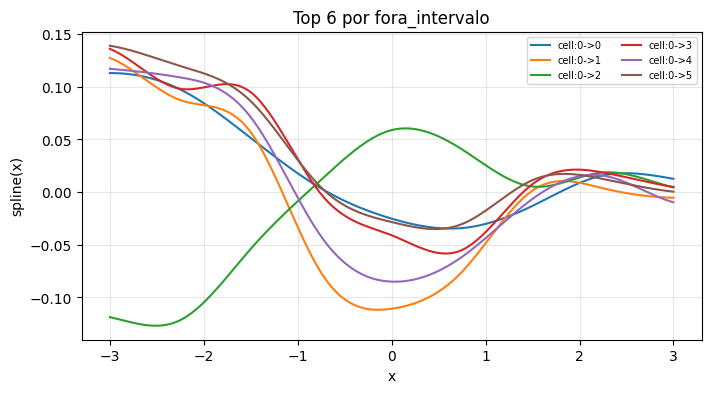

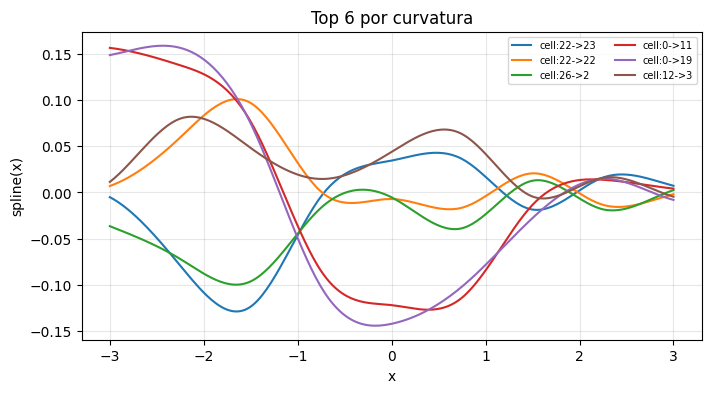

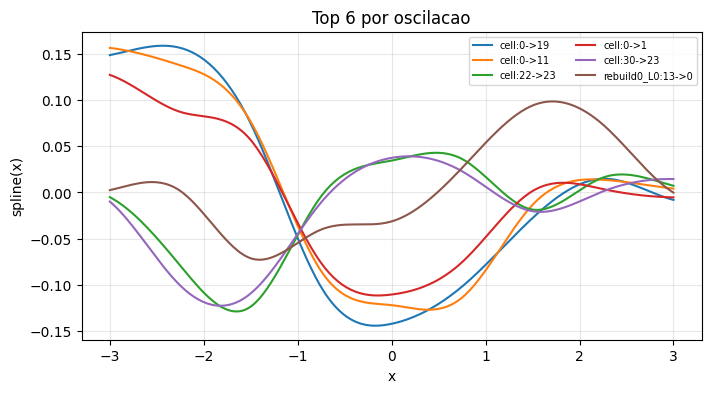

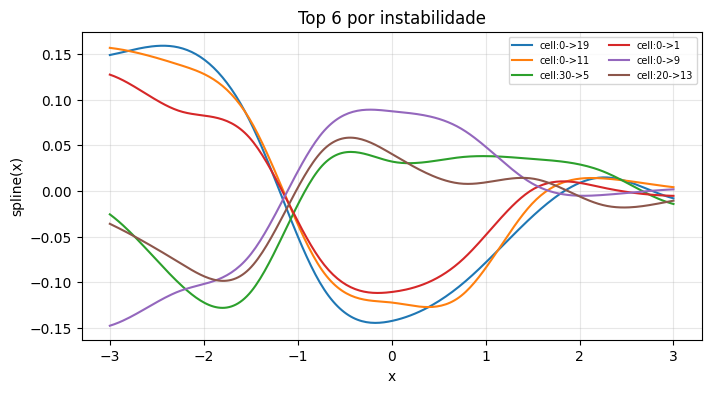

In [ ]:
# Plot das curvas das splines (Top-N por criterio)
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

x_min, x_max = -3.0, 3.0
num_samples = 256
x = torch.linspace(x_min, x_max, steps=num_samples).unsqueeze(1)  # (N,1)


def _eval_spline(grid, coef, k):
    grid_t = torch.tensor(grid, dtype=torch.float32)
    coef_t = torch.tensor(coef, dtype=torch.float32)
    y = coef2curve(x, grid_t, coef_t, k)  # (N, in_dim, out_dim)
    return y.squeeze(1)  # (N, out_dim)


def _metrics(y):
    y_np = y.detach().cpu().numpy()
    out_of_range = np.mean((y_np < x_min) | (y_np > x_max))
    dy = np.gradient(y_np, axis=0)
    d2y = np.gradient(dy, axis=0)
    curvature = np.mean(np.abs(d2y))
    total_var = np.mean(np.abs(np.diff(y_np, axis=0)))
    max_jump = np.max(np.abs(np.diff(y_np, axis=0)))
    return out_of_range, curvature, total_var, max_jump


def _rank_layers(layer, prefix):
    in_dim = layer.get('in_dim', 0)
    out_dim = layer.get('out_dim', 0)
    k = layer.get('k', None)
    grid = layer.get('grid', None)
    coef = layer.get('coef', None)
    if grid is None or coef is None:
        return []
    rows = []
    for i in range(in_dim):
        for o in range(out_dim):
            y = _eval_spline([grid[i]], [[coef[i][o]]], k)  # (N,1)
            oor, curv, tv, jump = _metrics(y)
            rows.append((prefix, i, o, oor, curv, tv, jump, grid[i], coef[i][o], k))
    return rows

rows = []
rows.extend(_rank_layers(data['kan_cell']['layers'][0], 'cell'))
for h, head in enumerate(data.get('kan_out', [])):
    for li, layer in enumerate(head.get('layers', [])):
        rows.extend(_rank_layers(layer, f"out{h}_L{li}"))
for h, head in enumerate(data.get('kan_out_rebuild', [])):
    for li, layer in enumerate(head.get('layers', [])):
        rows.extend(_rank_layers(layer, f"rebuild{h}_L{li}"))

# escolha criterio
criterios = {
    'fora_intervalo': 3,
    'curvatura': 4,
    'oscilacao': 5,
    'instabilidade': 6,
}

TOP_N = 6

for nome, idx in criterios.items():
    top = sorted(rows, key=lambda r: r[idx], reverse=True)[:TOP_N]
    plt.figure(figsize=(8, 4))
    for (prefix, i, o, oor, curv, tv, jump, grid, coef, k) in top:
        y = _eval_spline([grid], [[coef]], k).squeeze(1).numpy()
        label = f"{prefix}:{i}->{o}"
        plt.plot(x.numpy().squeeze(), y, label=label)
    plt.title(f"Top {TOP_N} por {nome}")
    plt.xlabel('x')
    plt.ylabel('spline(x)')
    plt.legend(fontsize=7, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()


'f(x)= 0.0844493\\,\\phi(x) + 0.204124\\,(-0.00183103 B_{0,3}(x) + -0.0121711 B_{1,3}(x) + -0.031181 B_{2,3}(x) + -0.0012585 B_{3,3}(x) + -0.0152203 B_{4,3}(x) + 0.00423471 B_{5,3}(x) + 0.000588002 B_{6,3}(x) + 0.0239461 B_{7,3}(x) + -0.0199208 B_{8,3}(x) + 0.00161947 B_{9,3}(x) + 0.00230573 B_{10,3}(x))'

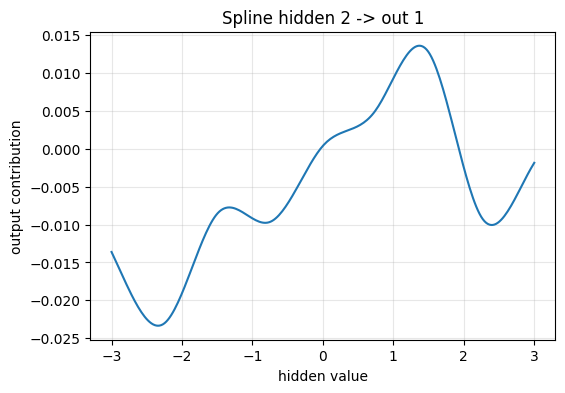

In [ ]:
# Plot hidden -> out (escolha indices)
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

# escolha aqui
h = 2  # hidden index
out = 1  # output index

# pega spline do kan_out (head = out)
layer = data['kan_out'][out]['layers'][0]

k = layer['k']
# grid shape: (in_dim, G+2k)
# coef shape: (in_dim, out_dim, G+k) -- aqui out_dim=1

grid = layer['grid'][h]
coef = layer['coef'][h][0]

x_min, x_max = -3.0, 3.0
x = torch.linspace(x_min, x_max, steps=256).unsqueeze(1)  # (N,1)

y = coef2curve(x, torch.tensor([grid], dtype=torch.float32), torch.tensor([[coef]], dtype=torch.float32), k)
# y shape (N,1,1)

y = y.squeeze().detach().cpu().numpy()


c_list = ", ".join([f"c_{j}" for j in range(len(coef))])
latex = rf"f(x)=\,\alpha\,\phi(x)+\beta\,\sum_{{j=0}}^{{{len(coef)-1}}} c_j B_{{j,{k}}}(x)"


# formula (LaTeX com coeficientes numericos)
alpha = float(0.0)
beta = float(1.0)
try:
    # tenta ler scale_base/scale_sp se existirem no JSON
    alpha = float(layer.get("scale_base", [[0]])[h][0])
    beta = float(layer.get("scale_sp", [[1]])[h][0])
except Exception:
    pass
coef_tex = " + ".join([f"{c:.6g} B_{{{j},{k}}}(x)" for j, c in enumerate(coef)])
latex = rf"f(x)= {alpha:.6g}\,\phi(x) + {beta:.6g}\,({coef_tex})"
display(latex)

plt.figure(figsize=(6,4))
plt.plot(x.numpy().squeeze(), y)
plt.title(f"Spline hidden {h} -> out {out}")
plt.xlabel('hidden value')
plt.ylabel('output contribution')
plt.grid(True, alpha=0.3)
plt.show()




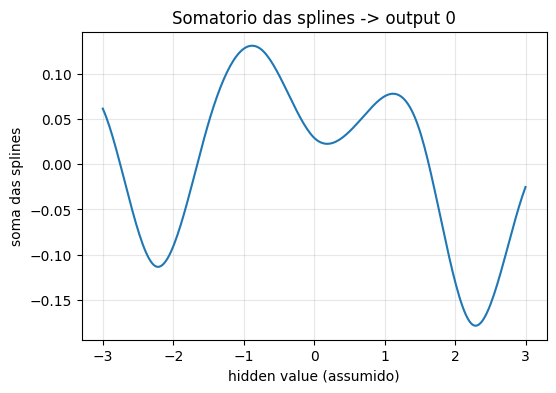

In [ ]:
# Somatorio de todas as splines para gerar output (por head)
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

# escolha o output head
out = 0  # 0..output_dim-1

layer = data['kan_out'][out]['layers'][0]

k = layer['k']
# grid shape: (in_dim, G+2k)
# coef shape: (in_dim, out_dim, G+k) -- aqui out_dim=1

grid = layer['grid']
coef = layer['coef']

x_min, x_max = -3.0, 3.0
x = torch.linspace(x_min, x_max, steps=256).unsqueeze(1)  # (N,1)

# soma das splines de todos os hidden -> output
sum_y = torch.zeros(x.shape[0])
for h in range(len(grid)):
    y = coef2curve(x, torch.tensor([grid[h]], dtype=torch.float32), torch.tensor([[coef[h][0]]], dtype=torch.float32), k)
    sum_y += y.squeeze()

plt.figure(figsize=(6,4))
plt.plot(x.numpy().squeeze(), sum_y.detach().cpu().numpy())
plt.title(f"Somatorio das splines -> output {out}")
plt.xlabel('hidden value (assumido)')
plt.ylabel('soma das splines')
plt.grid(True, alpha=0.3)
plt.show()


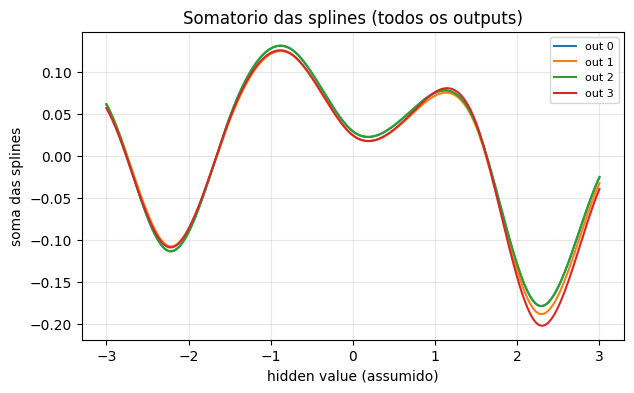

In [ ]:
# Somatorio das splines para TODOS os outputs em um unico grafico
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

x_min, x_max = -3.0, 3.0
x = torch.linspace(x_min, x_max, steps=256).unsqueeze(1)  # (N,1)

plt.figure(figsize=(7,4))

for out, head in enumerate(data['kan_out']):
    layer = head['layers'][0]
    k = layer['k']
    grid = layer['grid']
    coef = layer['coef']

    sum_y = torch.zeros(x.shape[0])
    for h in range(len(grid)):
        y = coef2curve(x, torch.tensor([grid[h]], dtype=torch.float32), torch.tensor([[coef[h][0]]], dtype=torch.float32), k)
        sum_y += y.squeeze()

    plt.plot(x.numpy().squeeze(), sum_y.detach().cpu().numpy(), label=f"out {out}")

plt.title("Somatorio das splines (todos os outputs)")
plt.xlabel('hidden value (assumido)')
plt.ylabel('soma das splines')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.show()


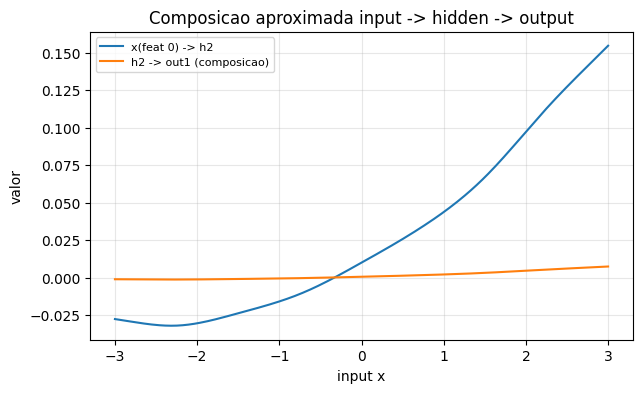

In [ ]:
# Composicao aproximada: input -> hidden -> output (sem recorrencia)
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

# escolha indices
feat = 0   # entrada (feature index)
h = 2      # hidden index
out = 1    # output index

x_min, x_max = -3.0, 3.0
x = torch.linspace(x_min, x_max, steps=256).unsqueeze(1)  # (N,1)

# helper: base_fun

def _base_fun(name):
    if name is None:
        return torch.nn.Identity()
    n = name.lower()
    if 'silu' in n:
        return torch.nn.SiLU()
    if 'relu' in n:
        return torch.nn.ReLU()
    return torch.nn.Identity()


def _eval_conn(layer, in_idx, out_idx, x_in):
    k = layer['k']
    grid = layer['grid'][in_idx]
    coef = layer['coef'][in_idx][out_idx]
    scale_sp = layer.get('scale_sp', None)
    scale_base = layer.get('scale_base', None)
    base_fun_name = layer.get('base_fun', None)

    y = coef2curve(x_in, torch.tensor([grid], dtype=torch.float32), torch.tensor([[coef]], dtype=torch.float32), k)
    y = y.squeeze()

    # inclui base se existir
    if scale_sp is not None and scale_base is not None:
        sp = float(scale_sp[in_idx][out_idx])
        sb = float(scale_base[in_idx][out_idx])
        phi = _base_fun(base_fun_name)(x_in.squeeze())
        y = sp * y + sb * phi
    return y

# kan_cell: input -> hidden
cell_layer = data['kan_cell']['layers'][0]
h_from_x = _eval_conn(cell_layer, feat, h, x)

# kan_out: hidden -> output
out_layer = data['kan_out'][out]['layers'][0]
y_from_h = _eval_conn(out_layer, h, 0, h_from_x.unsqueeze(1))

# plots
plt.figure(figsize=(7,4))
plt.plot(x.numpy().squeeze(), h_from_x.detach().cpu().numpy(), label=f"x(feat {feat}) -> h{h}")
plt.plot(x.numpy().squeeze(), y_from_h.detach().cpu().numpy(), label=f"h{h} -> out{out} (composicao)")
plt.title("Composicao aproximada input -> hidden -> output")
plt.xlabel('input x')
plt.ylabel('valor')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.show()


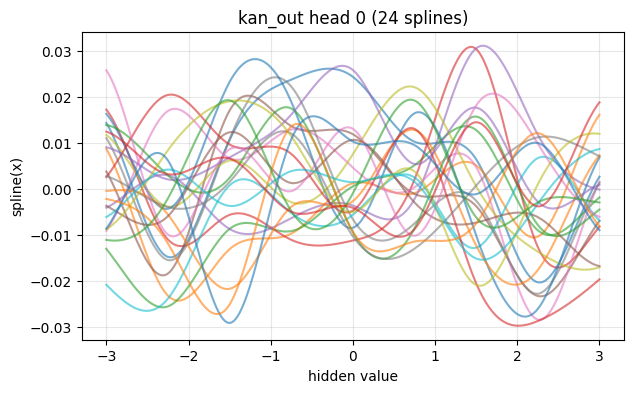

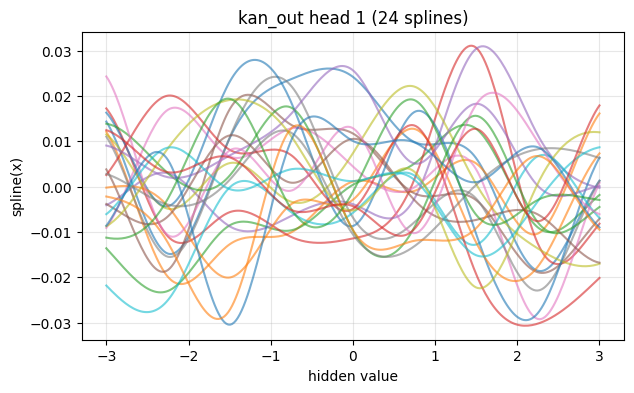

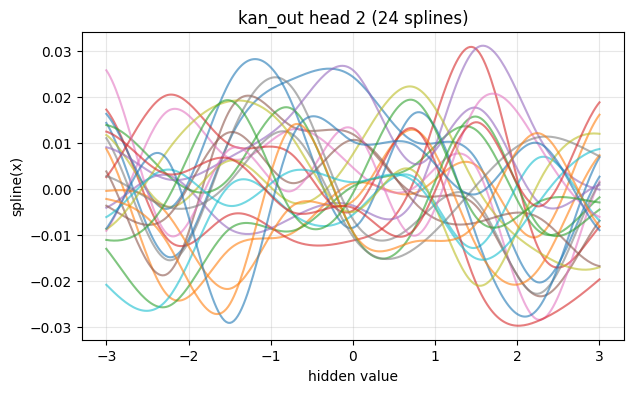

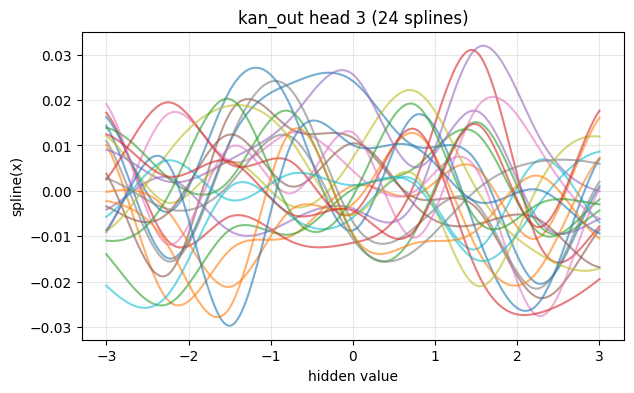

In [ ]:
# Plotar as 24 splines de cada head do kan_out (um grafico por head)
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

x_min, x_max = -3.0, 3.0
x = torch.linspace(x_min, x_max, steps=256).unsqueeze(1)  # (N,1)

for out, head in enumerate(data['kan_out']):
    layer = head['layers'][0]
    k = layer['k']
    grid = layer['grid']
    coef = layer['coef']

    plt.figure(figsize=(7,4))
    for h in range(len(grid)):
        y = coef2curve(x, torch.tensor([grid[h]], dtype=torch.float32), torch.tensor([[coef[h][0]]], dtype=torch.float32), k)
        plt.plot(x.numpy().squeeze(), y.squeeze().detach().cpu().numpy(), alpha=0.6)
    plt.title(f"kan_out head {out} (24 splines)")
    plt.xlabel('hidden value')
    plt.ylabel('spline(x)')
    plt.grid(True, alpha=0.3)
    plt.show()


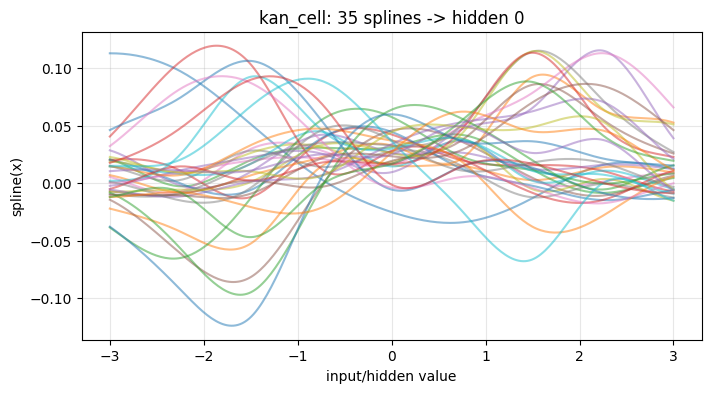

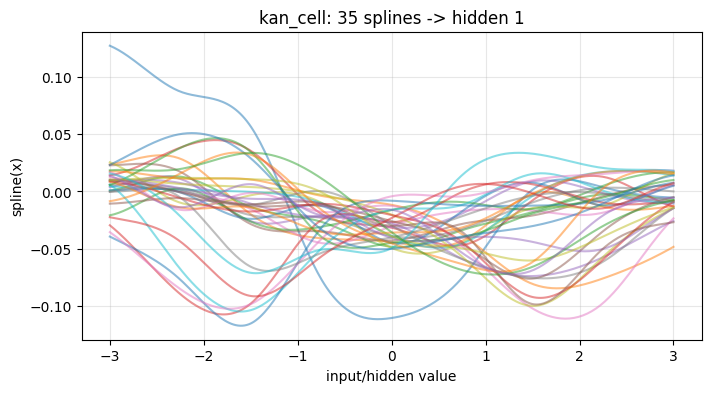

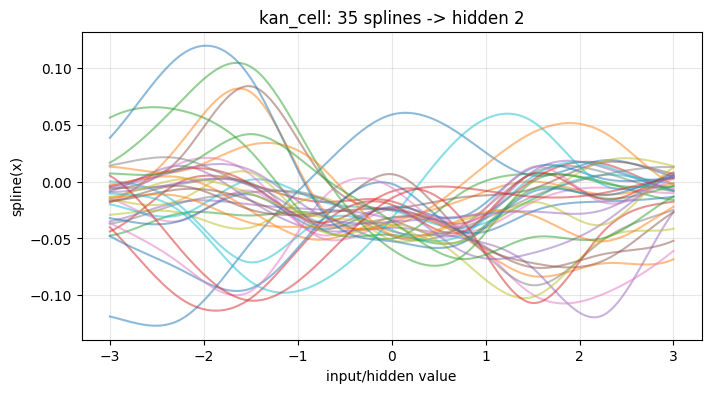

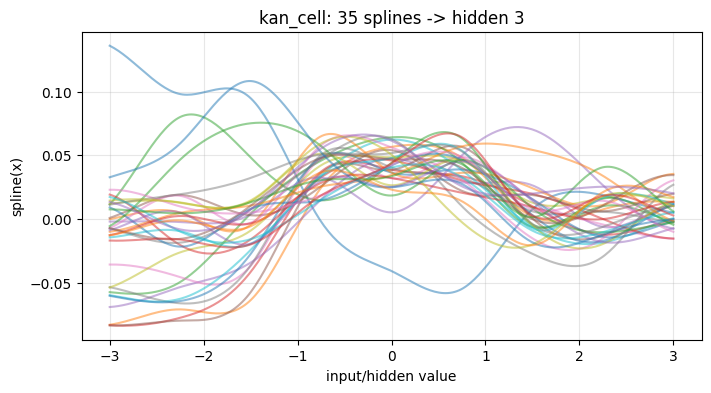

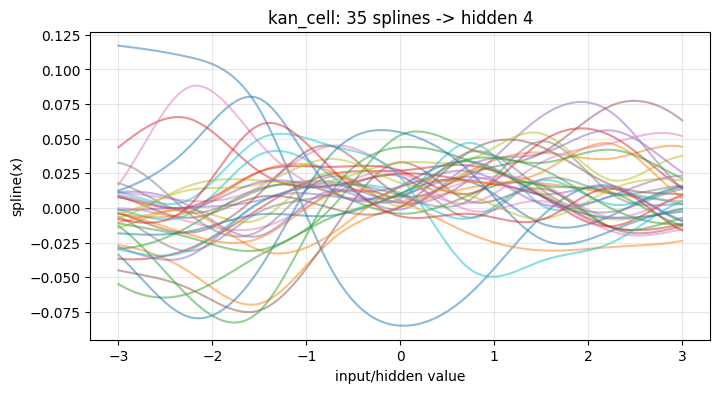

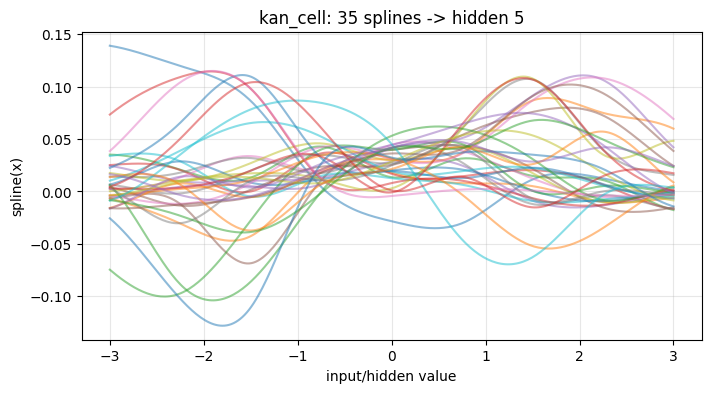

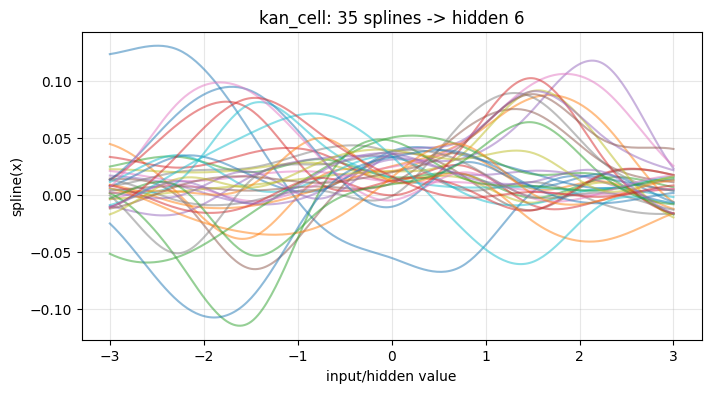

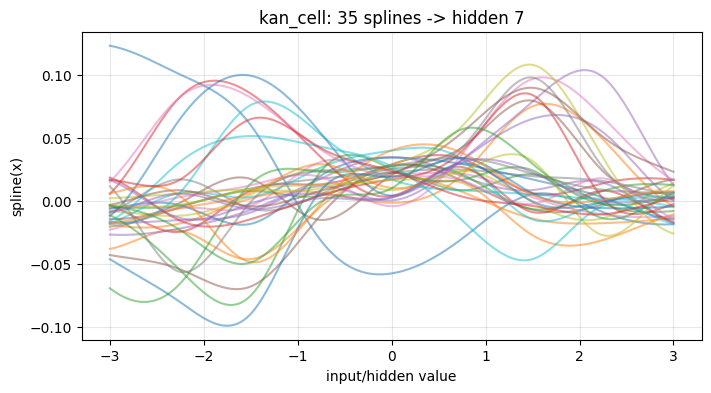

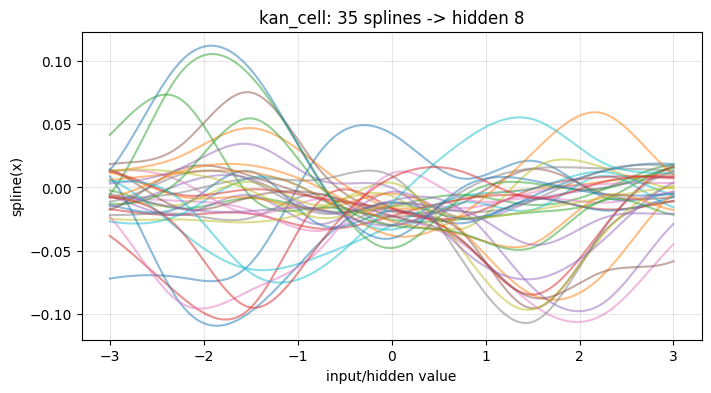

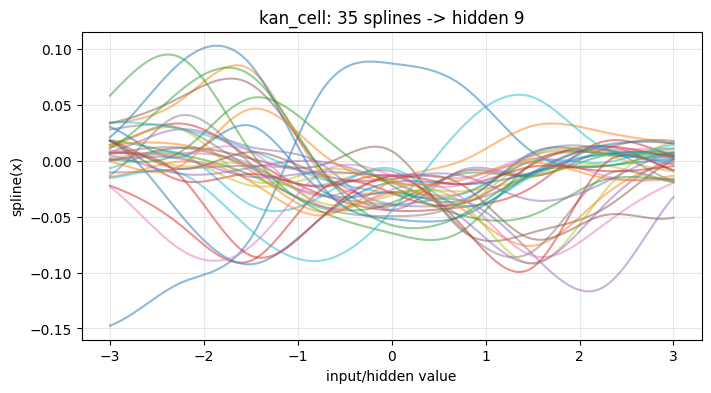

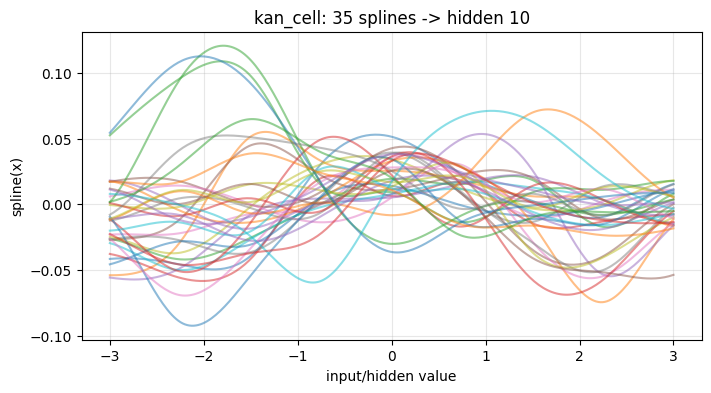

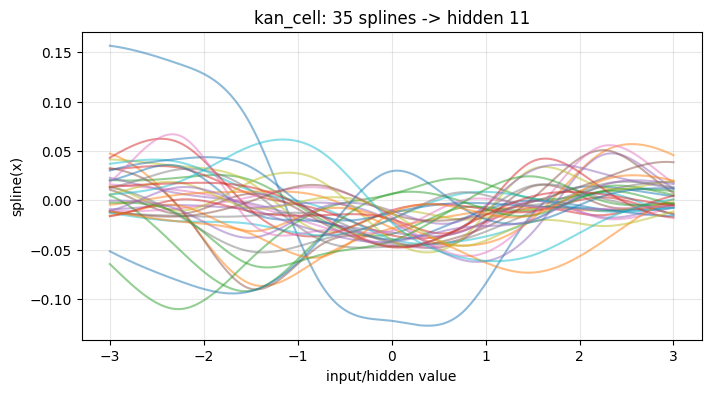

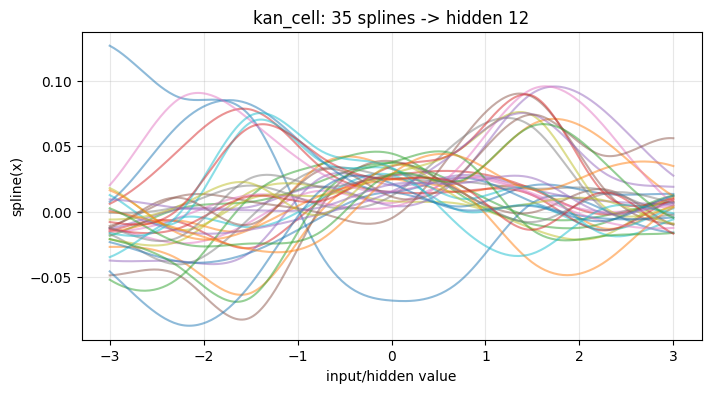

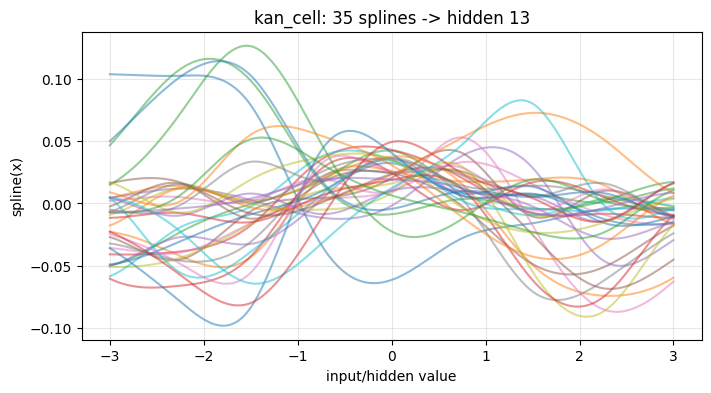

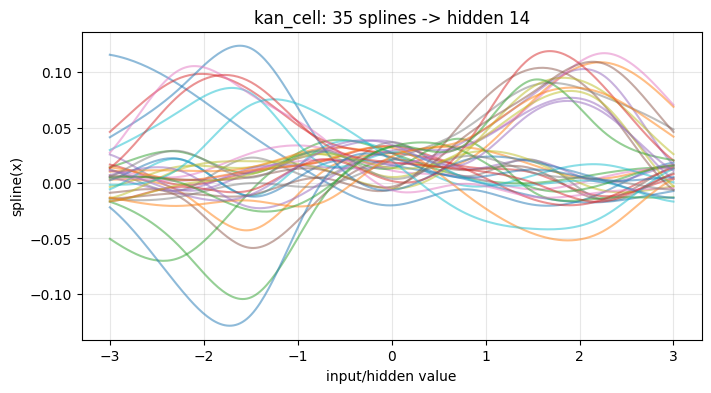

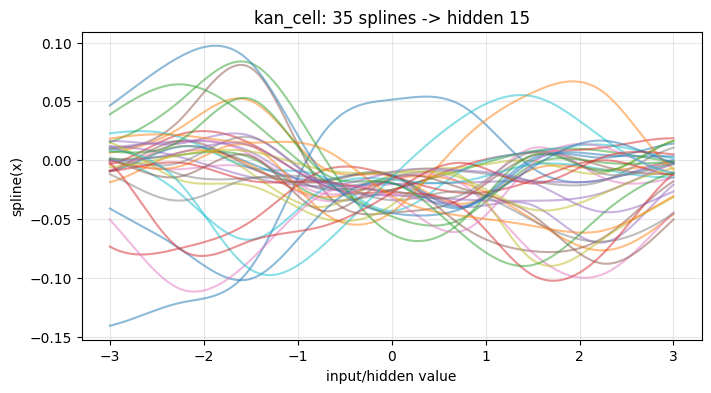

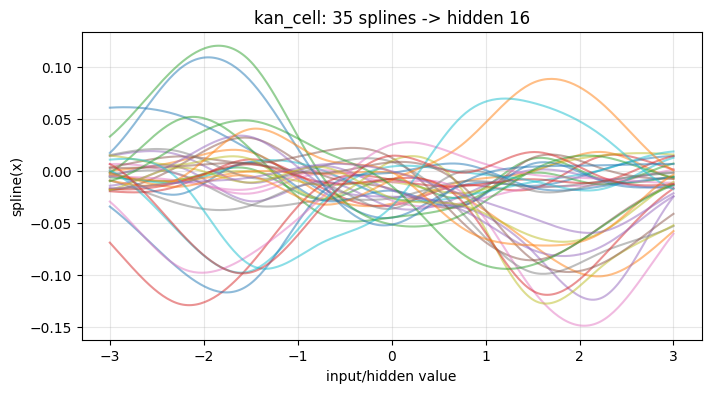

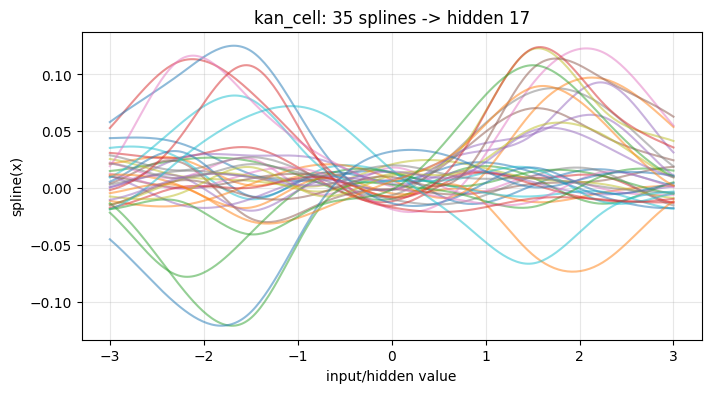

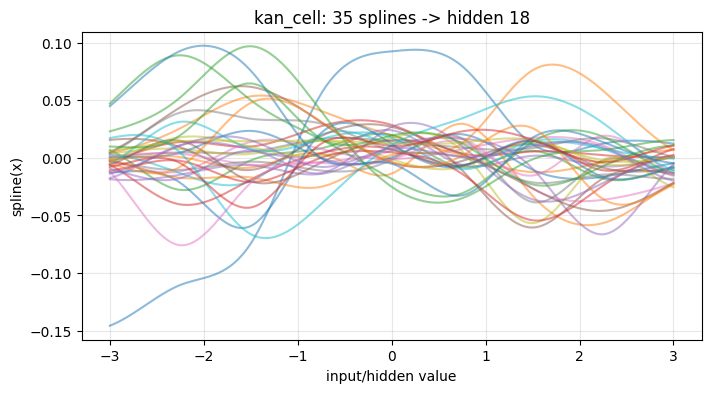

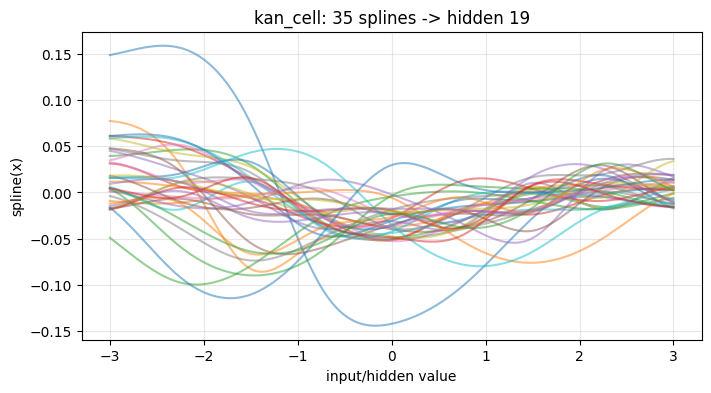

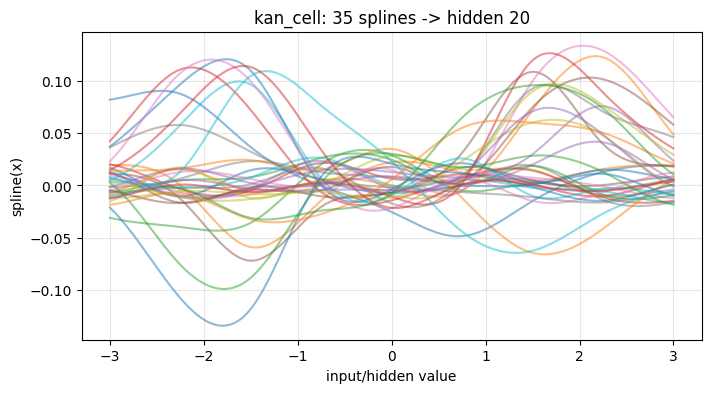

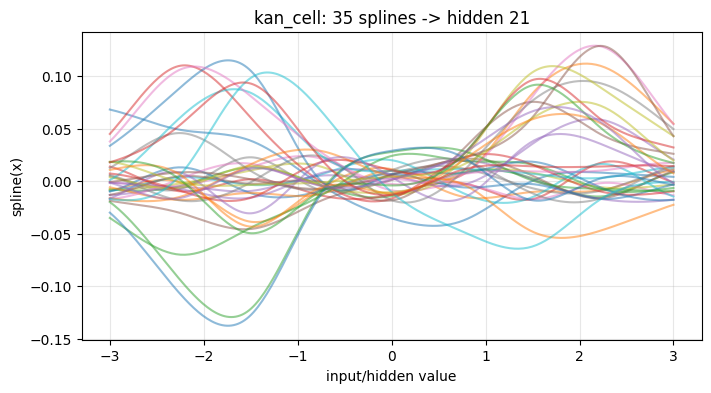

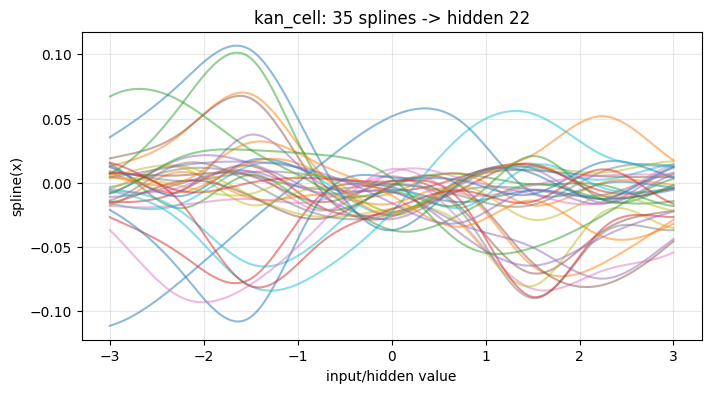

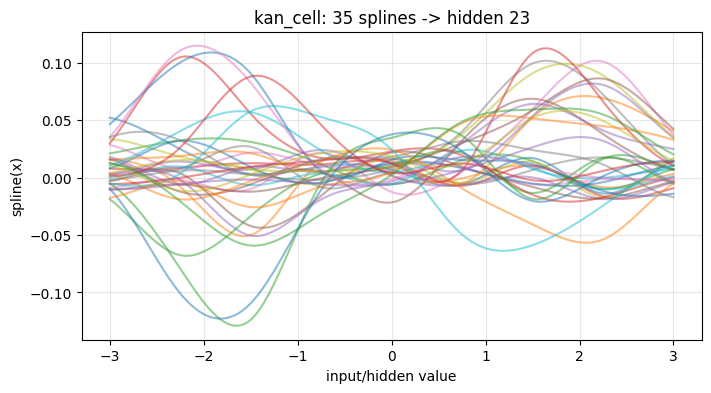

In [ ]:
# Plot das 35 splines que entram em CADA hidden (24 graficos)
import json
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

layer = data['kan_cell']['layers'][0]

k = layer['k']
# grid shape: (in_dim, G+2k)
# coef shape: (in_dim, out_dim, G+k)

grid = layer['grid']
coef = layer['coef']

x_min, x_max = -3.0, 3.0
x = torch.linspace(x_min, x_max, steps=256).unsqueeze(1)  # (N,1)

hidden_dim = layer['out_dim']

for h in range(hidden_dim):
    plt.figure(figsize=(8,4))
    for i in range(len(grid)):  # 35 entradas
        y = coef2curve(x, torch.tensor([grid[i]], dtype=torch.float32), torch.tensor([[coef[i][h]]], dtype=torch.float32), k)
        plt.plot(x.numpy().squeeze(), y.squeeze().detach().cpu().numpy(), alpha=0.5)

    plt.title(f"kan_cell: 35 splines -> hidden {h}")
    plt.xlabel('input/hidden value')
    plt.ylabel('spline(x)')
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
# Ajuste de modelos físicos candidatos nas splines (ranking por R2)
import json
import numpy as np
import torch
from pathlib import Path
from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

x_min, x_max = -3.0, 3.0
num_samples = 256
x = torch.linspace(x_min, x_max, steps=num_samples).unsqueeze(1)

def _eval_spline(grid, coef, k):
    grid_t = torch.tensor(grid, dtype=torch.float32)
    coef_t = torch.tensor(coef, dtype=torch.float32)
    y = coef2curve(x, grid_t, coef_t, k)
    return y.squeeze(1).detach().cpu().numpy()

def _r2(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else -np.inf

def fit_linear(x, y):
    p = np.polyfit(x, y, 1)
    yhat = np.polyval(p, x)
    return _r2(y, yhat), p

def fit_quadratic(x, y):
    p = np.polyfit(x, y, 2)
    yhat = np.polyval(p, x)
    return _r2(y, yhat), p

def fit_cubic(x, y):
    p = np.polyfit(x, y, 3)
    yhat = np.polyval(p, x)
    return _r2(y, yhat), p

def fit_exponential(x, y):
    mask = y > 0
    if mask.sum() < 10:
        return -np.inf, None
    X = x[mask]
    Y = np.log(y[mask])
    p = np.polyfit(X, Y, 1)
    a = np.exp(p[1])
    b = p[0]
    yhat = a * np.exp(b * x)
    return _r2(y, yhat), (a, b)

def fit_power(x, y):
    mask = (x > 0) & (y > 0)
    if mask.sum() < 10:
        return -np.inf, None
    X = np.log(x[mask])
    Y = np.log(y[mask])
    p = np.polyfit(X, Y, 1)
    a = np.exp(p[1])
    b = p[0]
    yhat = a * np.power(np.maximum(x, 1e-6), b)
    return _r2(y, yhat), (a, b)

def fit_arrhenius(x, y):
    mask = (x > 0) & (y > 0)
    if mask.sum() < 10:
        return -np.inf, None
    X = 1.0 / x[mask]
    Y = np.log(y[mask])
    p = np.polyfit(X, Y, 1)
    a = np.exp(p[1])
    b = -p[0]
    yhat = a * np.exp(-b / np.maximum(x, 1e-6))
    return _r2(y, yhat), (a, b)

models = {
    'linear': fit_linear,
    'quadratic': fit_quadratic,
    'cubic': fit_cubic,
    'exponential': fit_exponential,
    'power': fit_power,
    'arrhenius': fit_arrhenius,
}

def iter_splines():
    for li, layer in enumerate(data['kan_cell']['layers']):
        in_dim = layer['in_dim']; out_dim = layer['out_dim']; k = layer['k']
        grid = layer['grid']; coef = layer['coef']
        for i in range(in_dim):
            for o in range(out_dim):
                y = _eval_spline([grid[i]], [[coef[i][o]]], k)
                yield (f'cell_L{li}', i, o, y)
    for h, head in enumerate(data.get('kan_out', [])):
        for li, layer in enumerate(head.get('layers', [])):
            in_dim = layer['in_dim']; out_dim = layer['out_dim']; k = layer['k']
            grid = layer['grid']; coef = layer['coef']
            for i in range(in_dim):
                for o in range(out_dim):
                    y = _eval_spline([grid[i]], [[coef[i][o]]], k)
                    yield (f'out{h}_L{li}', i, o, y)
    for h, head in enumerate(data.get('kan_out_rebuild', [])):
        for li, layer in enumerate(head.get('layers', [])):
            in_dim = layer['in_dim']; out_dim = layer['out_dim']; k = layer['k']
            grid = layer['grid']; coef = layer['coef']
            for i in range(in_dim):
                for o in range(out_dim):
                    y = _eval_spline([grid[i]], [[coef[i][o]]], k)
                    yield (f'rebuild{h}_L{li}', i, o, y)

results = {name: [] for name in models}
x_np = x.squeeze(1).numpy()

for prefix, i, o, y in iter_splines():
    for name, fitter in models.items():
        r2, params = fitter(x_np, y)
        if np.isfinite(r2):
            results[name].append((r2, prefix, i, o, params))

TOP_K = 5
for name, rows in results.items():
    rows = sorted(rows, key=lambda r: r[0], reverse=True)[:TOP_K]
    print('\nModelo: {}'.format(name))
    for r2, prefix, i, o, params in rows:
        print('  {}:{}->{} | R2={:.4f} | params={}'.format(prefix, i, o, r2, params))



Modelo: linear
  out0_L0:13->0 | R2=0.7171 | params=[-0.00791007 -0.00145692]


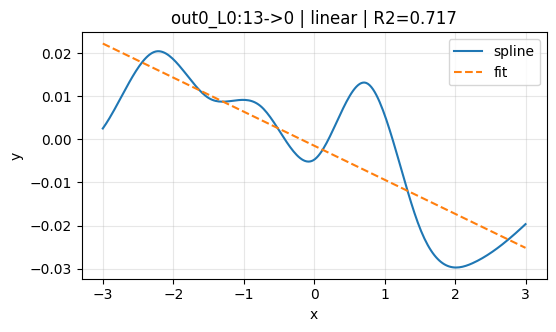

  out2_L0:13->0 | R2=0.7171 | params=[-0.00791007 -0.00145692]


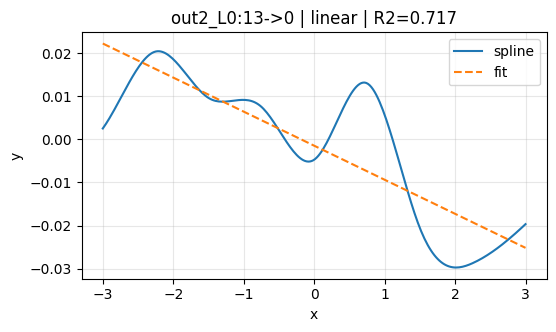

  out1_L0:13->0 | R2=0.7047 | params=[-0.0078561  -0.00183734]


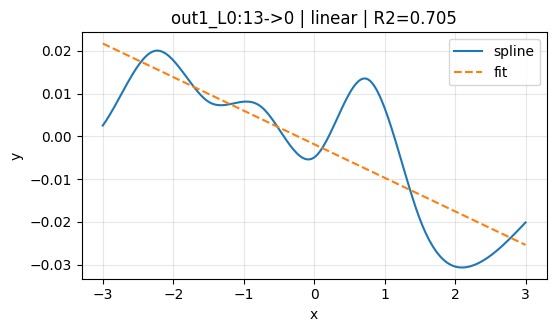

  out3_L0:13->0 | R2=0.6924 | params=[-0.00715167 -0.0014742 ]


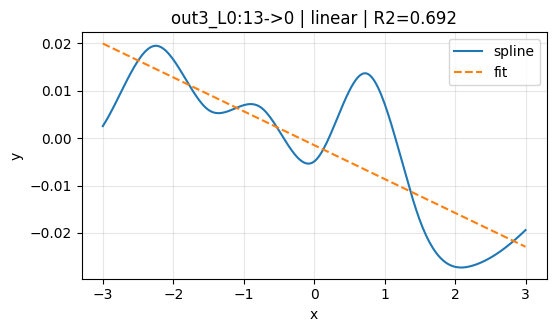

  out1_L0:6->0 | R2=0.4659 | params=[-0.0047615   0.00126549]


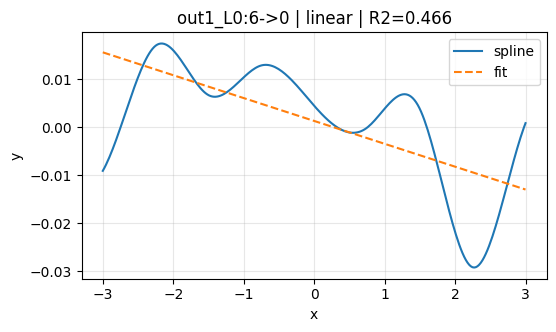


Modelo: quadratic
  out0_L0:13->0 | R2=0.7791 | params=[-0.00149499 -0.00791007  0.00306323]


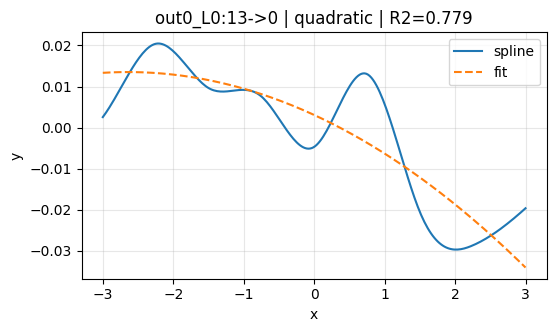

  out2_L0:13->0 | R2=0.7791 | params=[-0.00149499 -0.00791007  0.00306323]


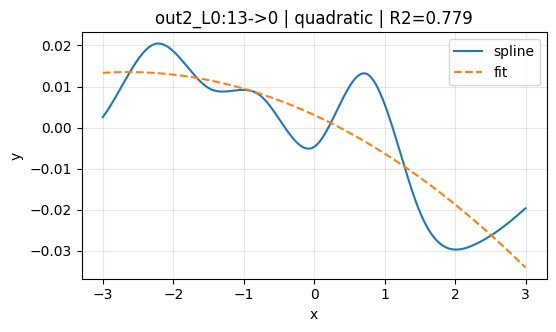

  out1_L0:13->0 | R2=0.7725 | params=[-0.00156802 -0.0078561   0.00290361]


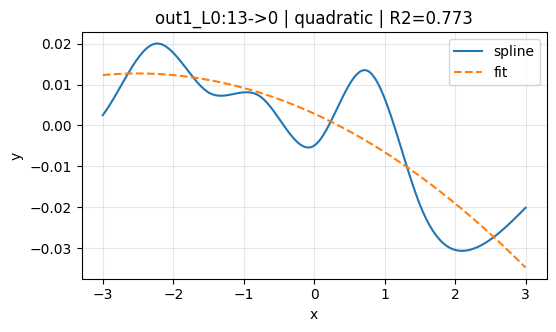

  out3_L0:13->0 | R2=0.7567 | params=[-0.00140161 -0.00715167  0.00276361]


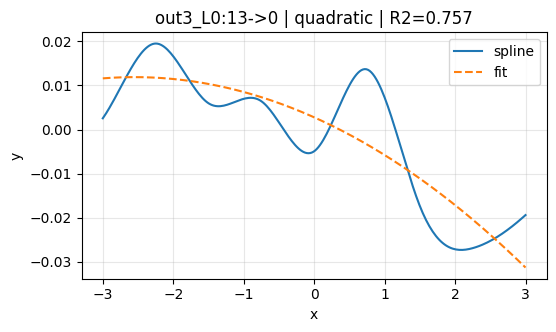

  out3_L0:2->0 | R2=0.7176 | params=[-0.00203591  0.00402633  0.00064236]


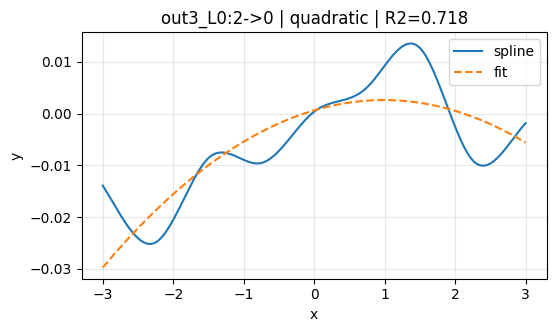


Modelo: cubic
  out3_L0:2->0 | R2=0.8267 | params=[-0.00084097 -0.00203591  0.00860308  0.00064236]


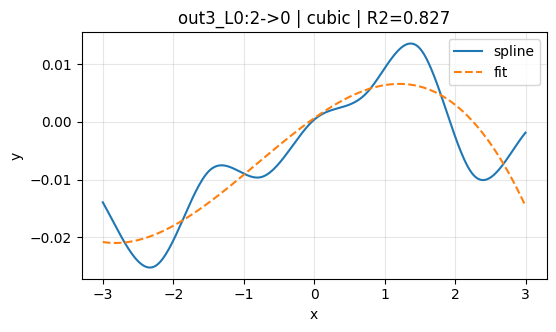

  out0_L0:2->0 | R2=0.8246 | params=[-0.00086218 -0.0020502   0.00873496  0.00071668]


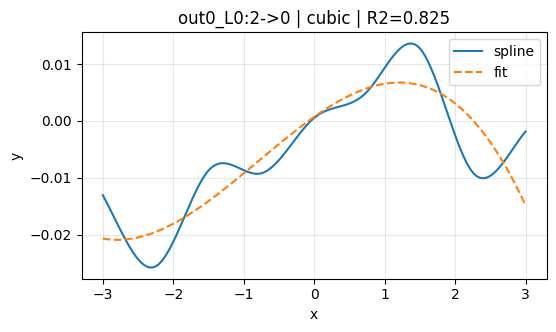

  out2_L0:2->0 | R2=0.8246 | params=[-0.00086218 -0.0020502   0.00873496  0.00071668]


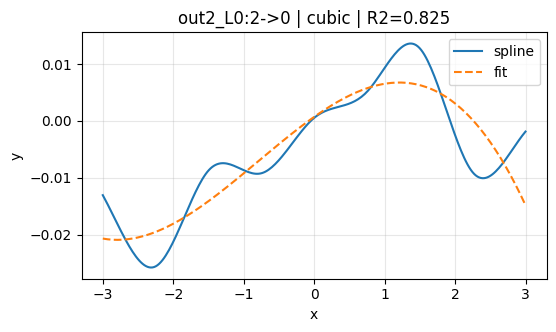

  out1_L0:2->0 | R2=0.8240 | params=[-0.00085417 -0.00193886  0.00847177  0.00061042]


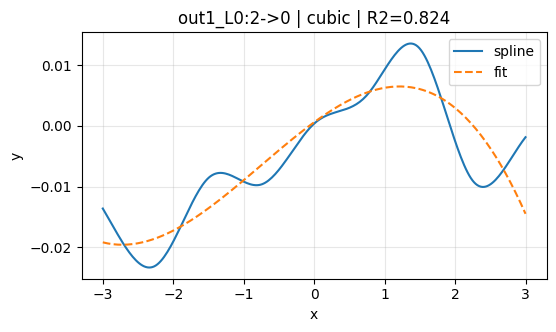

  out1_L0:18->0 | R2=0.7877 | params=[ 0.0022621   0.00026347 -0.01463306  0.00136998]


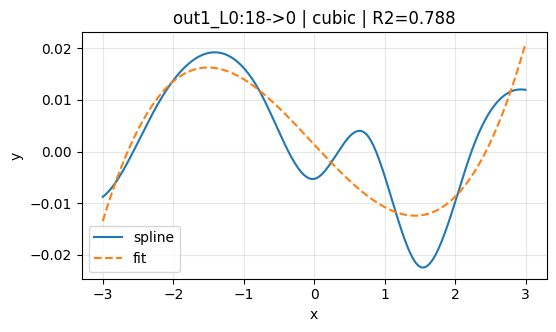


Modelo: exponential
  out3_L0:4->0 | R2=0.1635 | params=(0.004506308584606593, 0.31537870569119214)


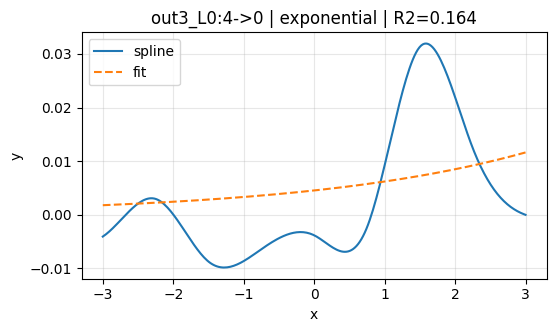

  out0_L0:4->0 | R2=0.1574 | params=(0.004256329040257646, 0.30770136388226377)


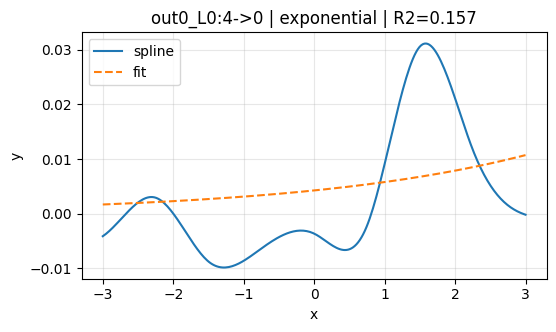

  out2_L0:4->0 | R2=0.1574 | params=(0.004256329040257646, 0.30770136388226377)


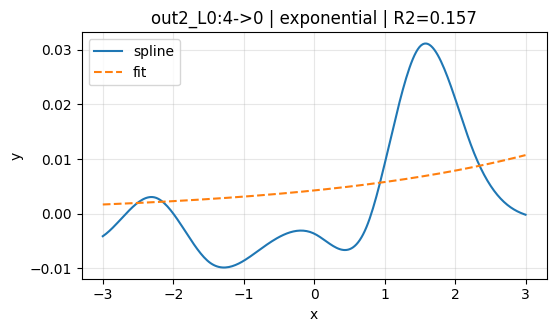

  out1_L0:4->0 | R2=0.1474 | params=(0.0043537091922049125, 0.30601795439241114)


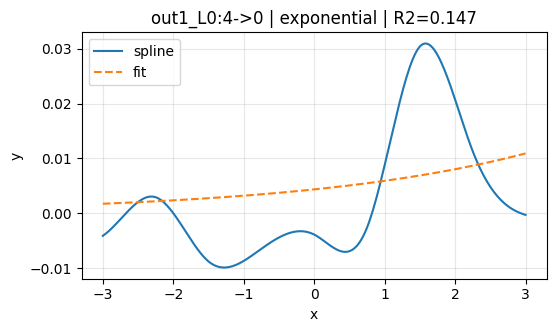

  out1_L0:6->0 | R2=0.0910 | params=(0.004759551025132543, -0.3744659952457502)


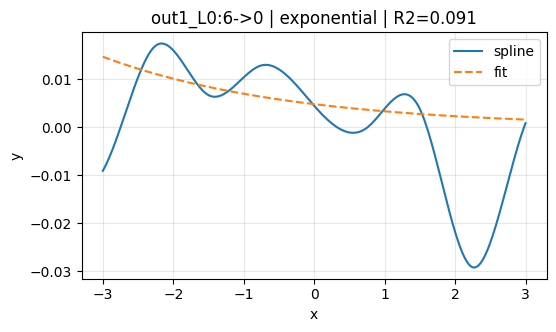


Modelo: power
  out0_L0:17->0 | R2=0.2008 | params=(0.0010284747346325648, 2.4462958453666035)


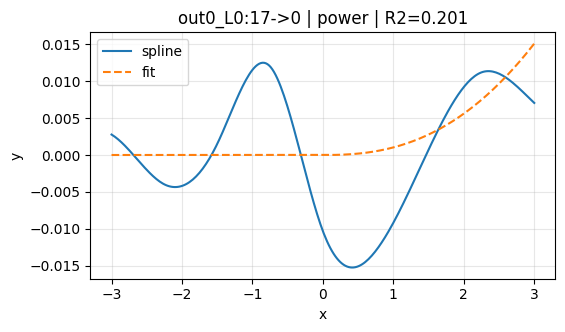

  out2_L0:17->0 | R2=0.2008 | params=(0.0010284747346325648, 2.4462958453666035)


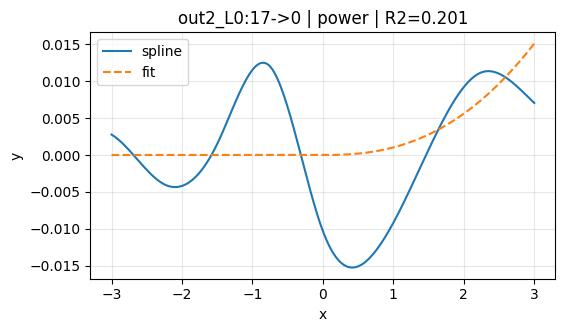

  out1_L0:17->0 | R2=0.1289 | params=(0.0009513741094182364, 2.260870546293912)


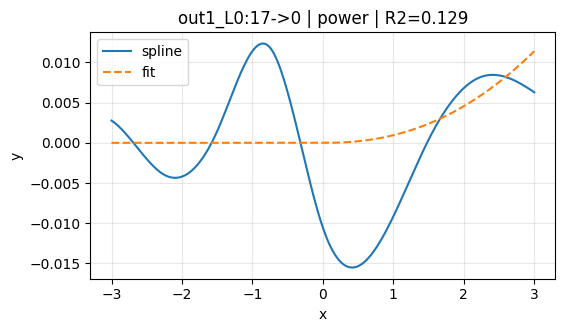

  out3_L0:17->0 | R2=0.0967 | params=(0.0005523752861626291, 2.671192812720984)


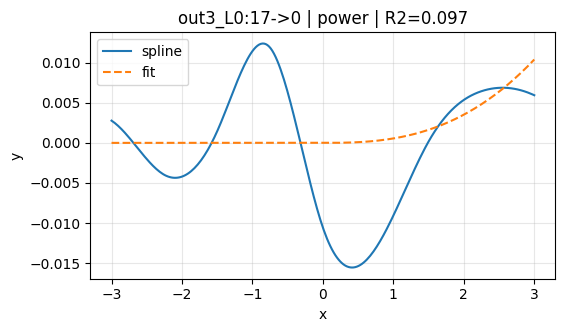

  out0_L0:16->0 | R2=-0.0530 | params=(0.008211727207403536, 0.03856891536697897)


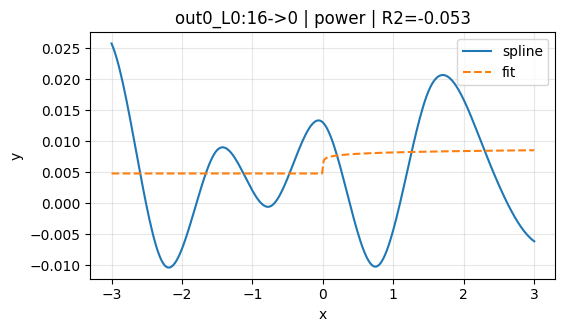


Modelo: arrhenius
  out0_L0:17->0 | R2=0.2284 | params=(0.09544689702458363, 5.59966989207761)


/tmp/ipykernel_158395/450511360.py:70: RuntimeWarning: overflow encountered in exp
  yhat = a * np.exp(-b / np.maximum(x, 1e-6))
/tmp/ipykernel_158395/450511360.py:24: RuntimeWarning: overflow encountered in square
  ss_res = np.sum((y - yhat) ** 2)


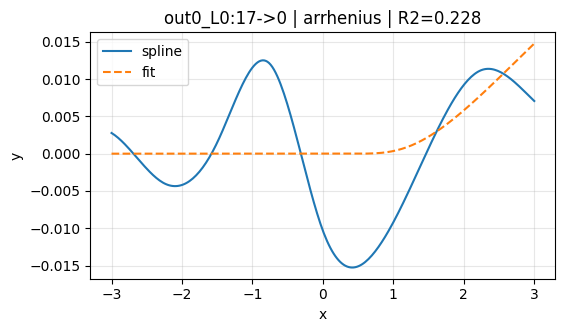

  out2_L0:17->0 | R2=0.2284 | params=(0.09544689702458363, 5.59966989207761)


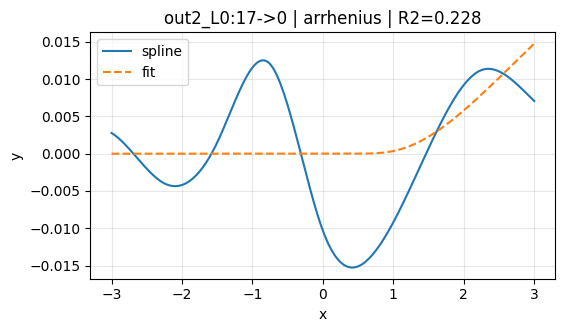

  out1_L0:17->0 | R2=0.1557 | params=(0.06166726463751339, 5.148580038696607)


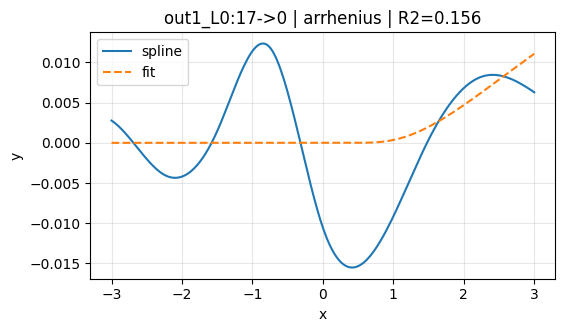

  out3_L0:17->0 | R2=0.1129 | params=(0.07457683180574487, 6.0326292741642265)


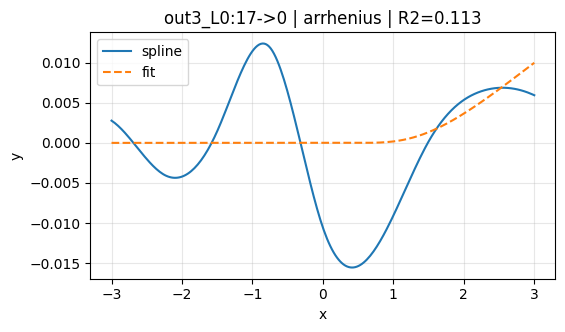

  out0_L0:23->0 | R2=-0.0171 | params=(0.008945280632799242, 0.4474204135272017)


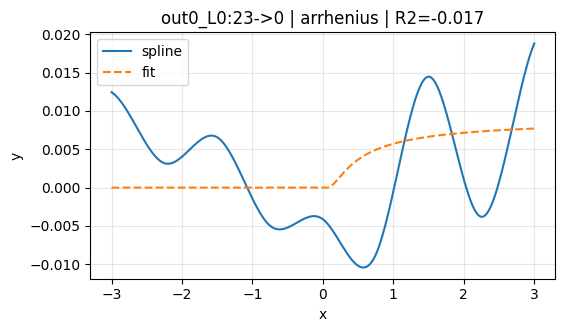

In [ ]:
# Somente kan_out: ajustar modelos e plotar spline vs ajuste
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from seqkan.kan.spline import coef2curve

spl_path = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/seqKANseq_splines.json')
data = json.loads(spl_path.read_text())

x_min, x_max = -3.0, 3.0
num_samples = 256
x = torch.linspace(x_min, x_max, steps=num_samples).unsqueeze(1)
x_np = x.squeeze(1).numpy()

def _eval_spline(grid, coef, k):
    grid_t = torch.tensor(grid, dtype=torch.float32)
    coef_t = torch.tensor(coef, dtype=torch.float32)
    y = coef2curve(x, grid_t, coef_t, k)
    return y.squeeze().detach().cpu().numpy()

def _r2(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else -np.inf

def fit_linear(x, y):
    p = np.polyfit(x, y, 1)
    return _r2(y, np.polyval(p, x)), ('linear', p)

def fit_quadratic(x, y):
    p = np.polyfit(x, y, 2)
    return _r2(y, np.polyval(p, x)), ('quadratic', p)

def fit_cubic(x, y):
    p = np.polyfit(x, y, 3)
    return _r2(y, np.polyval(p, x)), ('cubic', p)

def fit_exponential(x, y):
    mask = y > 0
    if mask.sum() < 10:
        return -np.inf, ('exponential', None)
    X = x[mask]
    Y = np.log(y[mask])
    p = np.polyfit(X, Y, 1)
    a = np.exp(p[1]); b = p[0]
    yhat = a * np.exp(b * x)
    return _r2(y, yhat), ('exponential', (a, b))

def fit_power(x, y):
    mask = (x > 0) & (y > 0)
    if mask.sum() < 10:
        return -np.inf, ('power', None)
    X = np.log(x[mask])
    Y = np.log(y[mask])
    p = np.polyfit(X, Y, 1)
    a = np.exp(p[1]); b = p[0]
    yhat = a * np.power(np.maximum(x, 1e-6), b)
    return _r2(y, yhat), ('power', (a, b))

def fit_arrhenius(x, y):
    mask = (x > 0) & (y > 0)
    if mask.sum() < 10:
        return -np.inf, ('arrhenius', None)
    X = 1.0 / x[mask]
    Y = np.log(y[mask])
    p = np.polyfit(X, Y, 1)
    a = np.exp(p[1]); b = -p[0]
    yhat = a * np.exp(-b / np.maximum(x, 1e-6))
    return _r2(y, yhat), ('arrhenius', (a, b))

models = [fit_linear, fit_quadratic, fit_cubic, fit_exponential, fit_power, fit_arrhenius]

def iter_kan_out():
    for h, head in enumerate(data.get('kan_out', [])):
        for li, layer in enumerate(head.get('layers', [])):
            in_dim = layer['in_dim']; out_dim = layer['out_dim']; k = layer['k']
            grid = layer['grid']; coef = layer['coef']
            for i in range(in_dim):
                for o in range(out_dim):
                    y = _eval_spline([grid[i]], [[coef[i][o]]], k)
                    yield (f'out{h}_L{li}', i, o, y)

TOP_K = 5
for fit in models:
    name = fit(x_np, np.ones_like(x_np))[1][0]
    rows = []
    for prefix, i, o, y in iter_kan_out():
        y = np.asarray(y).reshape(-1)
        r2, meta = fit(x_np, y)
        if np.isfinite(r2):
            rows.append((r2, prefix, i, o, y, meta))
    rows = sorted(rows, key=lambda r: r[0], reverse=True)[:TOP_K]
    print('\nModelo:', name)
    for r2, prefix, i, o, y, meta in rows:
        print('  {}:{}->{} | R2={:.4f} | params={}'.format(prefix, i, o, r2, meta[1]))
        plt.figure(figsize=(6, 3.2))
        plt.plot(x_np, y, label='spline')
        if meta[0] in ['linear', 'quadratic', 'cubic']:
            yhat = np.polyval(meta[1], x_np)
        elif meta[0] == 'exponential' and meta[1] is not None:
            a, b = meta[1]; yhat = a * np.exp(b * x_np)
        elif meta[0] == 'power' and meta[1] is not None:
            a, b = meta[1]; yhat = a * np.power(np.maximum(x_np, 1e-6), b)
        elif meta[0] == 'arrhenius' and meta[1] is not None:
            a, b = meta[1]; yhat = a * np.exp(-b / np.maximum(x_np, 1e-6))
        else:
            yhat = None
        if yhat is not None:
            plt.plot(x_np, yhat, '--', label='fit')
        plt.title('{}'.format(prefix + ':' + str(i) + '->' + str(o) + ' | ' + meta[0] + ' | R2=' + format(r2, '.3f')))
        plt.xlabel('x'); plt.ylabel('y')
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.show()
